# **Signa_Lab ITESO: Depuración y análisis exploratorio de preguntas recibidas**

## **Proyecto:** *Selección de Preguntas de Redes Sociales para 1er Debate Presidencial INE 2024 (Formato A)*

Cuaderno de código diseñado para realizar análisis exploratorio y visualización de datos de los 13,484 registros recibidos y de las 21,219 preguntas de la población depurada tras la primera etapa de procesamiento de preguntas ciudadanas de redes sociales entregadas a Signa_Lab ITESO por el INE para el 1er Debate Presiencial de 2024.

## 1. Importar librerías y archivos de datos procesados
---



**Instalar librerías necesarias:**

In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install scipy
!pip install plotly

**Importar librerías necesarias:**

In [245]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.stats import gaussian_kde
import matplotlib.patches as patches
import plotly.express as px

**Importar archivos de datos procesados:**

In [246]:
# Rutas locales de archivos de datos a importar:
ruta_13kRegistros_1 = "./data/Corte1-Formulario-1erDebatePresidencial2024-03-22-00-03-15.xlsx"
ruta_13kRegistros_2 = "./data/Corte2-Formulario-1erDebatePresidencial2024-03-22-00-04-59.xlsx"
ruta_PreguntasEliminadas = "./data/20240325_1534_PreguntasDebateINE_PreguntasDescartadas.csv"
ruta_Poblacion21219 = "./data/20240325_1534_PreguntasDebateINE_PoblacionPreguntasDepuradas.csv"
ruta_Muestra1701 = "./data/20240325_1759_PreguntasDebateINE_MuestraEstratificada.csv"
ruta_108Preguntas = "./data/20240328_1900_PreguntasDebateINE_Seleccion_Final.csv"

# Leer archivos
df1 = pd.read_excel(ruta_13kRegistros_1)
df2 = pd.read_excel(ruta_13kRegistros_2)
dfRegistros = pd.concat([df1, df2])

dfPreguntasDescartadas = pd.read_csv(ruta_PreguntasEliminadas)

dfPoblacion21219 = pd.read_csv(ruta_Poblacion21219)

dfMuestra = pd.read_csv(ruta_Muestra1701)

df108Preguntas = pd.read_csv(ruta_108Preguntas)

Agregar **regiones, edad (números enteros) y rangos de edad:**

In [243]:
# Listado de entidades por región, definido por metodología, Anexo 1, del INE
regiones = {
    'norte': ['Baja California', 'Baja California Sur', 'Sonora', 'Chihuahua', 'Coahuila', 'Nuevo León', 'Tamaulipas', 'Sinaloa', 'Durango', 'Zacatecas', 'Nayarit'],
    'centro': ['Jalisco', 'Aguascalientes', 'San Luis Potosí', 'Querétaro', 'Ciudad de México', 'México', 'Michoacán', 'Colima', 'Tlaxcala', 'Morelos', 'Hidalgo', 'Guanajuato'],
    'sur': ['Veracruz', 'Tabasco', 'Campeche', 'Yucatán', 'Quintana Roo', 'Chiapas', 'Guerrero', 'Oaxaca', 'Puebla']
  }

# Function to get region based on state
def asignar_region(state):
    for region, states in regiones.items():
        if state in states:
            return region
    return None

dfRegistros['Region'] = dfRegistros['¿Cuál es tu entidad de origen?'].apply(asignar_region)
dfRegistros['Edad:'] = dfRegistros['Edad:'].apply(lambda x: int(x.split(' ')[0]))


bins = [13, 18, 23, 28, 33, 38, 43, 48, 53, 58, 63, 68,73,78,83,88,93,99]
labels = ['13-17', '18-22', '23-27', '28-32', '33-37', '38-42','43-47','48-52','53-57','58-62','63-67','68-72','73-77','78-82','83-87','88-92','93-99']

dfRegistros['rango_edad_c5'] = pd.cut(dfRegistros['Edad:'], bins=bins, labels=labels, right=False)

In [ ]:
# Previsualizar tabla de registros procesados
dfRegistros.head(3)

In [5]:
# Verificar número de filas y columnas en tabla de registros
dfRegistros.shape

(13484, 24)

## 2. Análisis Exploratorio de Registros Recibidos (Entradas a Formulario del INE)

### **13,484 Registros:**

**Variables originales** por registro:
- Edad
- Género
- Entidad de origen
- Pertenencia a Grupo en Situación de Discriminación
- Fecha de entrada

**Variable agregadas** por registro:
- Región
- Rango de edad

### Registros por Entidad y Región:

In [6]:
# Enlistar registros recibidos por región
dfRegistros['Region'].value_counts()

Region
centro    8329
sur       2867
norte     2288
Name: count, dtype: int64

Registros recibidos **por región:**

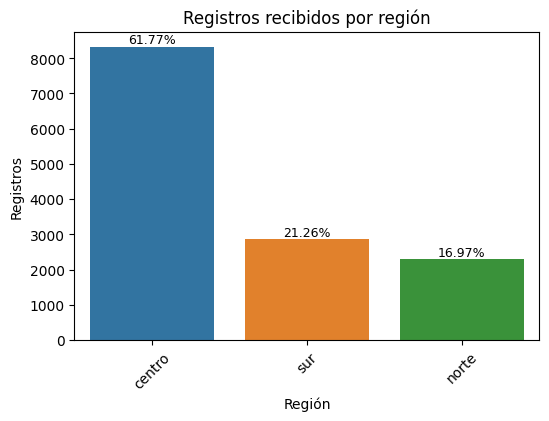

In [7]:
# Crear gráfica de registros por región
total_entries = len(dfRegistros)
counts = dfRegistros['Region'].value_counts()
percentage = counts / total_entries * 100

column = 'Region'
figsize = (6, 4)  # Ajusta el tamaño de la figura según tus preferencias
fig, ax = plt.subplots(figsize=figsize)
sns.barplot(x=counts.index, y=counts.values, order=counts.index, hue=counts.index, ax=ax)
plt.title(f'Registros recibidos por región')
plt.ylabel('Registros')
plt.xlabel('Región')
plt.xticks(rotation=45)
plt.grid(False)

# Añadir los valores de porcentaje en las barras
for index, value in enumerate(counts.values):
    ax.annotate(f'{percentage.iloc[index]:.2f}%', xy=(index, value), ha='center', va='bottom', fontsize=9)

plt.show()

Registros recibidos **por entidad:**

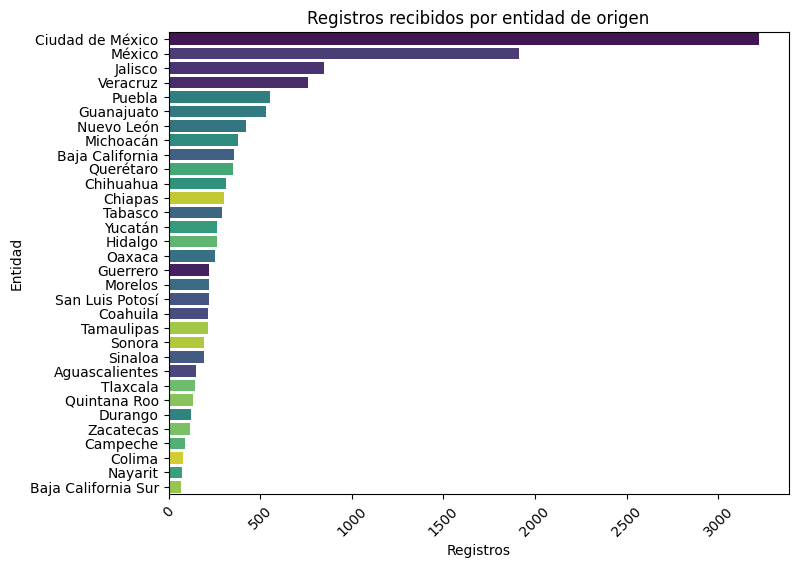

In [8]:
# Crear gráfica de registros por entidad
column = '¿Cuál es tu entidad de origen?'
figsize = (8,6)
orden = dfRegistros[column].value_counts().index
plt.figure(figsize=figsize)
sns.countplot(data=dfRegistros, y=column, hue=column, palette='viridis', order=orden, legend=False)
plt.title(f'Registros recibidos por entidad de origen')
plt.xlabel('Registros')
plt.ylabel('Entidad')
plt.xticks(rotation=45)
plt.show()

### Registros por Edad:

Distribución de registros **por edad:**

In [9]:
# Enlistar medidas para describir la distribución por edad
dfRegistros.describe()

,Edad:
count,13484.000000
mean,38.293311
std,17.870468
min,13.000000
25%,22.000000
50%,35.000000
75%,54.000000
max,99.000000


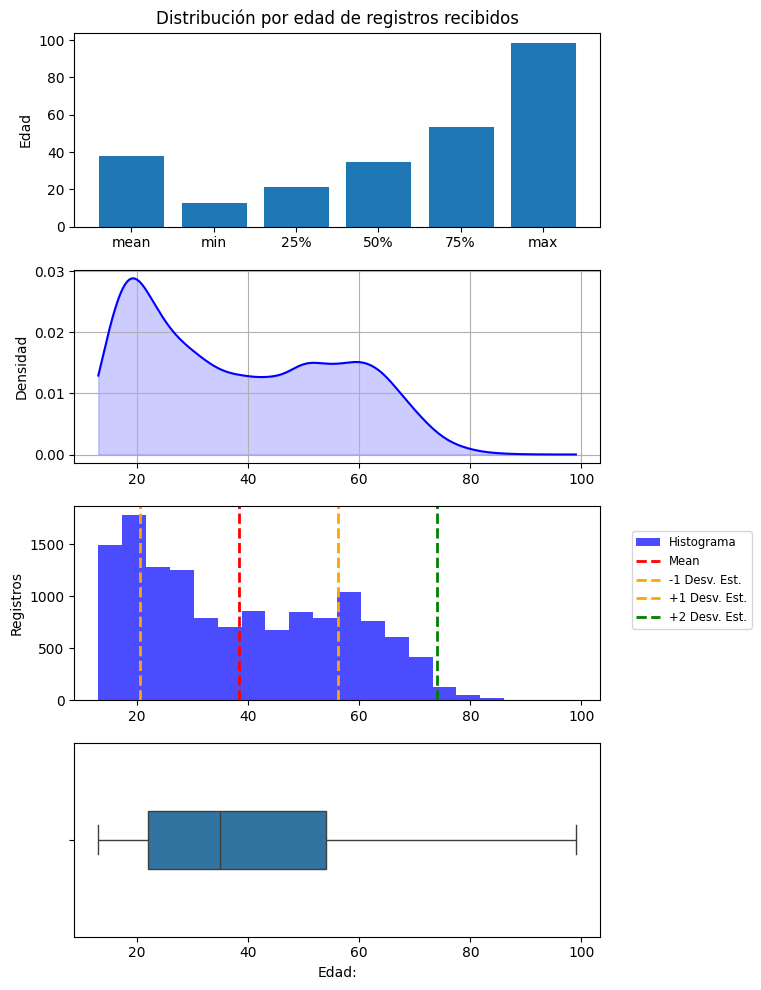

In [10]:
# Crear gráficas para visualizar registros por edad
column = 'Edad:'
x = dfRegistros[column].describe()

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8,10))

# Medidas de tendencia central
x_labels = ['mean', 'min', '25%', '50%', '75%', 'max']
x_values = [x[label] for label in x_labels]
y = np.arange(len(x_labels))

axes[0].bar(y, x_values, width=0.8, edgecolor="white", linewidth=0.7)
axes[0].set_xticks(y)
axes[0].set_xticklabels(x_labels)
axes[0].set_title(f'Distribución por edad de registros recibidos')
axes[0].set_ylabel('Edad')

# Estimación de la densidad de probabilidad
edad = dfRegistros['Edad:']
kde = gaussian_kde(edad)

# Valores en los que evaluar la función de densidad
x = np.linspace(min(edad), max(edad), 1000)

# Función de densidad de probabilidad (PDF)
pdf = kde.evaluate(x)

# Visualización de la función de densidad de probabilidad
axes[1].plot(x, pdf, color='blue', label='PDF')
axes[1].fill_between(x, pdf, color='blue', alpha=.2)

axes[1].set_ylabel('Densidad')
axes[1].grid(True)

# Gráfica de barras con distribución por edad
n, bins, patches = axes[2].hist(dfRegistros[column], bins=20, density=False, alpha=0.7, color='blue', label='Histograma')
axes[2].axvline(x_values[0], color='red', linestyle='dashed', linewidth=2, label='Mean')
std = dfRegistros['Edad:'].std() # Corrected line
axes[2].axvline(x_values[0] - std, color='orange', linestyle='dashed', linewidth=2, label='-1 Desv. Est.')
axes[2].axvline(x_values[0] + std, color='orange', linestyle='dashed', linewidth=2, label='+1 Desv. Est.')
axes[2].axvline(x_values[0] + 2 * std, color='green', linestyle='dashed', linewidth=2, label='+2 Desv. Est.')
axes[2].set_ylabel('Registros')
axes[2].legend(fontsize='small',bbox_to_anchor=(1.3, .9))

# Boxplot con distribución por edad
sns.boxplot(x=dfRegistros["Edad:"], width=.3, ax=axes[3])
axes[3].set_xlabel(column)
axes[3].set_ylabel('')

plt.tight_layout()
plt.show()

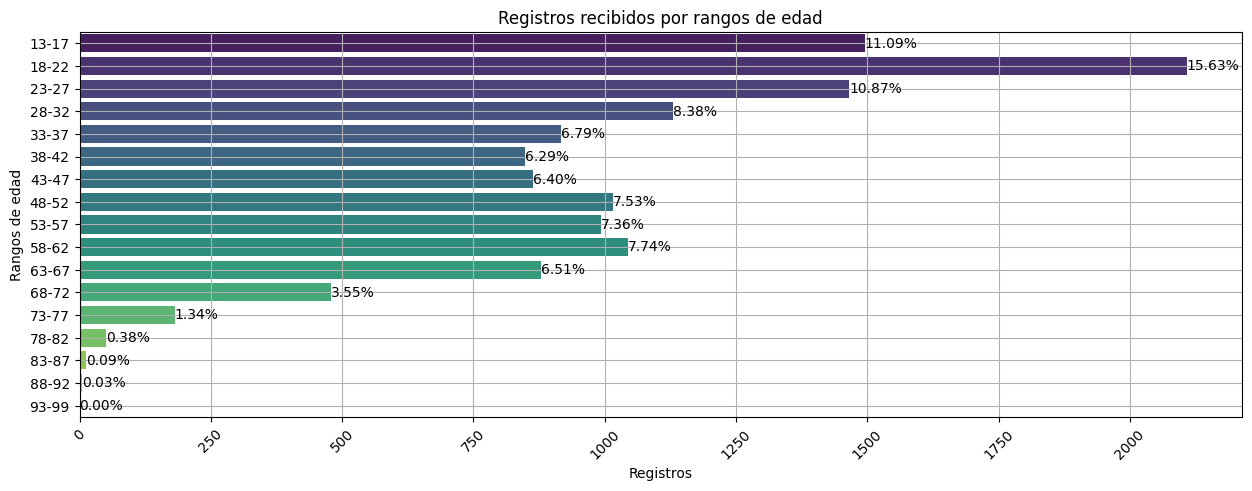

In [11]:
# Crear gráfica de distribución por rangos de edad
total_entries = len(dfRegistros)
counts = dfRegistros['rango_edad_c5'].value_counts()
percentage = counts / total_entries * 100

# Definir el nuevo orden deseado
labels = ['13-17', '18-22', '23-27', '28-32', '33-37', '38-42','43-47','48-52','53-57','58-62','63-67','68-72','73-77','78-82','83-87','88-92','93-99']
# Crear la figura
figsize = (15, 5)
plt.figure(figsize=figsize)

# Crear el gráfico de barras con el nuevo orden especificado
sns.barplot(x=counts.values, y=counts.index, order=labels, palette='viridis', dodge=False, hue=counts.index, legend=False)

# Configurar el título y los ejes
plt.title(f'Registros recibidos por rangos de edad')
plt.xlabel('Registros')
plt.ylabel('Rangos de edad')
plt.xticks(rotation=45)
plt.grid(True)

# Añadir los valores de porcentaje en las barras en el nuevo orden correcto
for i, label in enumerate(labels):
    # Encontrar el índice del label en el índice de counts
    index = counts.index.get_loc(label)
    plt.text(counts.values[index], i, f'{percentage[label]:.2f}%', fontsize=10, va='center')

plt.show()

### **Registros por Género:**

In [12]:
# Enlistar valores de la columna 'Género:' los registros de mayor a menor frecuencia.
dfRegistros['Género:'].value_counts()

Género:
Masculino     8413
Femenino      4679
Selecciona     197
Otro           195
Name: count, dtype: int64

C:\Users\signalab\AppData\Local\Temp\ipykernel_17492\868697025.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Nulos (vacíos)', 'Válidos (respondidos)'], y=[cantidad_nulos, cantidad_no_nulos], palette=['red', 'green'])


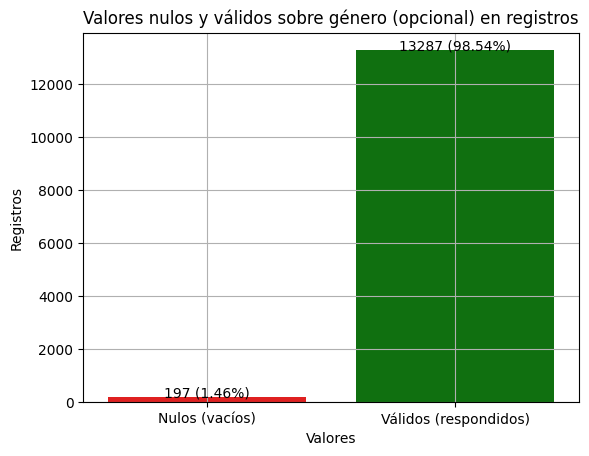

In [13]:
# Contar la cantidad de valores nulos en columna 'Género:' y calcular su porcentaje
cantidad_nulos = len(dfRegistros[dfRegistros['Género:'] == "Selecciona"])
cantidad_no_nulos = len(dfRegistros[dfRegistros['Género:'] != "Selecciona"])

# Calcular porcentajes
total_registros = len(dfRegistros)
porcentaje_nulos = (cantidad_nulos / total_registros) * 100
porcentaje_no_nulos = (cantidad_no_nulos / total_registros) * 100

# Crear DataFrame temporal para el gráfico
data = pd.DataFrame({
    'Valores': ['null', 'Count género'],
    'Cantidad': [porcentaje_nulos, porcentaje_no_nulos],
    'Tipo': ['null', 'Count género']
})

# Visualizar gráfica de valores nulos y válidos en columna 'Género:'
sns.barplot(x=['Nulos (vacíos)', 'Válidos (respondidos)'], y=[cantidad_nulos, cantidad_no_nulos], palette=['red', 'green'])
plt.xlabel('Valores')
plt.ylabel('Registros')
plt.title('Valores nulos y válidos sobre género (opcional) en registros')

# Agregar porcentajes encima de las barras
for i, valor in enumerate([cantidad_nulos, cantidad_no_nulos]):
    if i == 0:
        plt.text(i, valor + 0.5, f'{valor} ({porcentaje_nulos:.2f}%)', ha='center')
    else:
        plt.text(i, valor + 0.5, f'{valor} ({porcentaje_no_nulos:.2f}%)', ha='center')

plt.grid()
plt.show()

**Porcentaje de registros por género indicado** entre quienes sí respondieron:

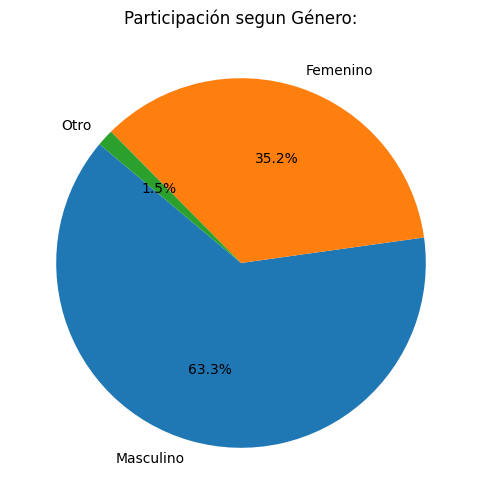

In [14]:
# Visualizar distribución entre registros donde se indicó el género entre las opciones ofrecidas ('Masculino', 'Femenino' y 'Otro')
column='Género:'
figsize=(8,6)
plt.figure(figsize=(8, 6))
dfRegistros[dfRegistros[column] != "Selecciona"][column].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title(f'Participación segun {column}')
plt.ylabel('')
plt.show()

### **Registros por Grupos en Situación de Discriminación:**

In [15]:
# Enlistar valores de la columna GSD en los registros de mayor a menor frecuencia.

dfRegistros['¿Te identificas con alguno de los siguientes Grupos en Situación de Discriminación?'].value_counts()

¿Te identificas con alguno de los siguientes Grupos en Situación de Discriminación?
Selecciona                                        7777
Personas adultas mayores                          2251
Personas de la diversidad sexual                  1472
Personas con discapacidad                          864
Personas indígenas                                 664
Personas mexicanas residentes en el extranjero     191
Personas migrantes                                 142
Personas afromexicanas                             123
Name: count, dtype: int64

C:\Users\signalab\AppData\Local\Temp\ipykernel_17492\2869863587.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Nulos (vacíos)', 'Válidos (respondidos)'], y=[cantidad_nulos, cantidad_no_nulos], palette=['red', 'green'])


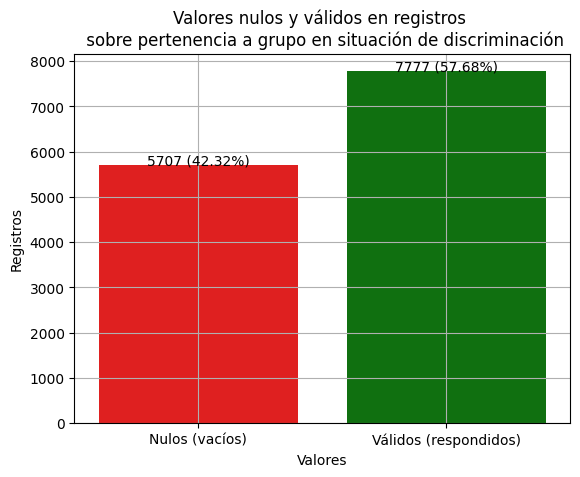

In [16]:
# Contamos la cantidad de nulos y calculoamos su porcentaje
cantidad_nulos = len(dfRegistros[dfRegistros["¿Te identificas con alguno de los siguientes Grupos en Situación de Discriminación?"] != "Selecciona"])
cantidad_no_nulos = len(dfRegistros[dfRegistros["¿Te identificas con alguno de los siguientes Grupos en Situación de Discriminación?"] == "Selecciona"])
pcntg_nulos = cantidad_nulos/len(dfRegistros)*100
pcntg_no_nulos = cantidad_no_nulos/len(dfRegistros)*100

# Crear un DataFrame temporal para el gráfico
data = pd.DataFrame({
    'Valores': ['Pertenecen a un GSD', 'No pertenecen a un GSD'],
    'Cantidad': [cantidad_no_nulos, cantidad_nulos],
    'Tipo': ['Pertenecen a un GSD', 'No pertenecen a un GSD']
})

# Visualizar gráfica de valores nulos y válidos en campo (opcional) de pertenencia a Grupo en Situación de Discriminación
sns.barplot(x=['Nulos (vacíos)', 'Válidos (respondidos)'], y=[cantidad_nulos, cantidad_no_nulos], palette=['red', 'green'])
plt.xlabel('Valores')
plt.ylabel('Registros')
plt.title('Valores nulos y válidos en registros \n sobre pertenencia a grupo en situación de discriminación')

#agregar los porcentajes
for i, valor in enumerate([cantidad_nulos, cantidad_no_nulos]):
    if i == 0:
        plt.text(i, valor + 0.5, f'{valor} ({pcntg_nulos:.2f}%)', ha='center')
    else:
        plt.text(i, valor + 0.5, f'{valor} ({pcntg_no_nulos:.2f}%)', ha='center')

plt.grid()
plt.show()

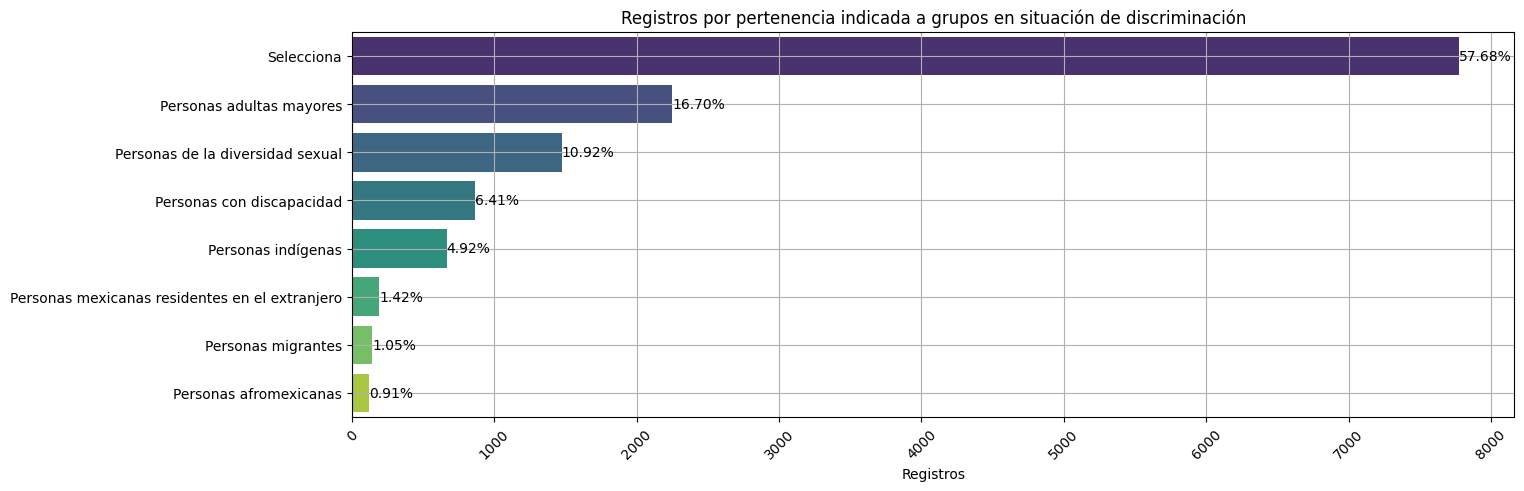

In [17]:
# Calcula el porcentaje de cada grupo
total_entries = counts.sum()
counts = dfRegistros['¿Te identificas con alguno de los siguientes Grupos en Situación de Discriminación?'].value_counts()
percentage = counts / total_entries * 100

# Crear gráfica de registros por pertenencia indicada a grupo en situación de discriminación
column = '¿Te identificas con alguno de los siguientes Grupos en Situación de Discriminación?'
figsize = (15, 5)
plt.figure(figsize=figsize)
sns.barplot(x=counts.values, y=counts.index,  palette='viridis', dodge=False, hue=counts.index, legend=False)
plt.title(f'Registros por pertenencia indicada a grupos en situación de discriminación')
plt.xlabel('Registros')
plt.ylabel('')
plt.xticks(rotation=45)
plt.grid(True)

# Añadir los valores de porcentaje en las barras
for i, val in enumerate(percentage):
    plt.text(counts.values[i], i, f'{val:.2f}%', fontsize=10, va='center')

plt.show()

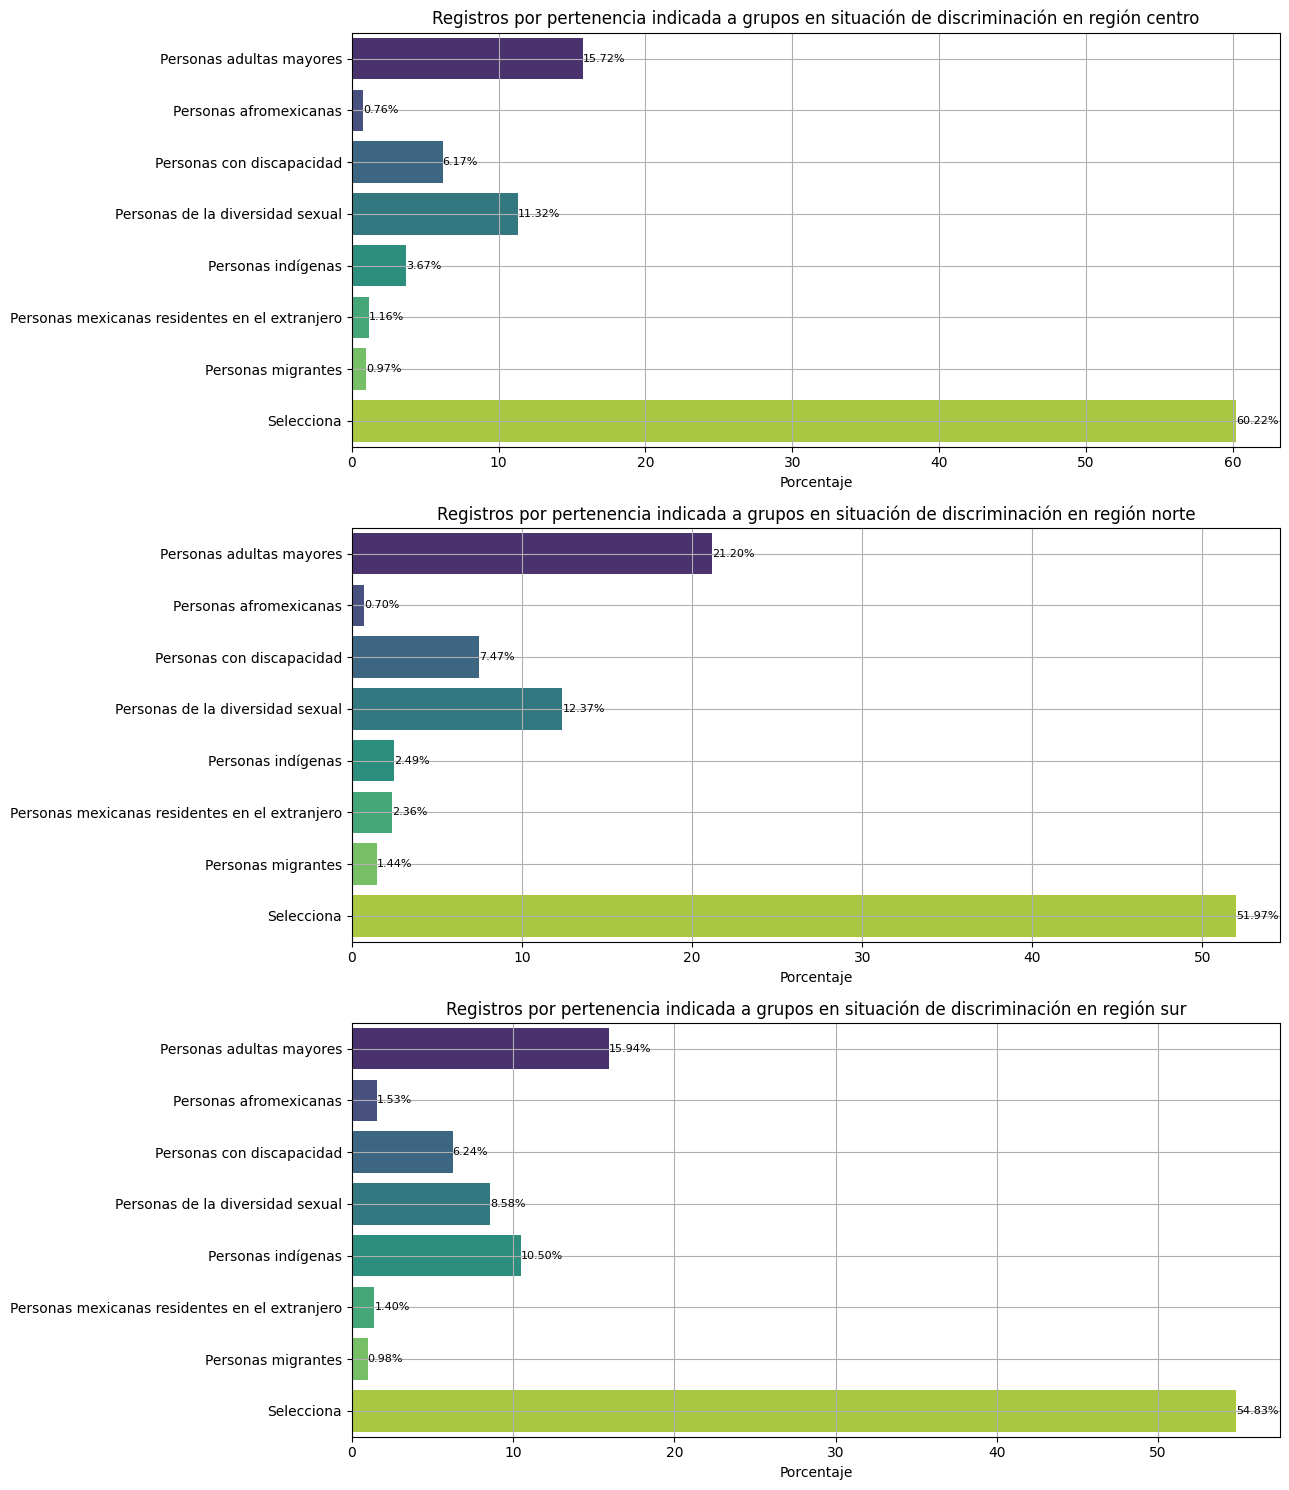

In [18]:
# Crear gráficas de porcentajes de registros por región por pertenencia indicada a grupo en situación de discriminación (opcional)
total_entries_region = dfRegistros.groupby('Region').size()
counts_region = dfRegistros.groupby(['Region', '¿Te identificas con alguno de los siguientes Grupos en Situación de Discriminación?']).size().unstack(fill_value=0)
percentage_region = counts_region.div(total_entries_region, axis=0) * 100

# Crear gráficas para cada región
fig, axes = plt.subplots(nrows=len(percentage_region), figsize=(13, 5 * len(percentage_region)))
fig.subplots_adjust(hspace=0.5)

for i, (region, data) in enumerate(percentage_region.iterrows()):
    sorted_data = data
    ax = sns.barplot(x=sorted_data.values, y=sorted_data.index, hue=counts.index, dodge=False, palette='viridis', ax=axes[i], legend=False)
    ax.set_title(f'Registros por pertenencia indicada a grupos en situación de discriminación en región {region}')
    ax.set_xlabel('Porcentaje')
    ax.set_ylabel('')
    ax.grid(True)

    # Añadir valores de porcentaje a cada barra
    for j, val in enumerate(sorted_data.values):
        ax.text(val, j, f'{val:.2f}%', fontsize=8, va='center')

plt.tight_layout()
plt.show()

### **Registros por fecha de entrada:**

In [19]:
# Función para convertir la cadena de fecha y hora en un objeto datetime, que toma el valor de 'Fecha de entrada', bajo su formato original'Día Mes, Año Hora AM/PM' en español
def strToDate(strDate):
    meses = {
        "enero,": 1,
        "febrero,": 2,
        "marzo,": 3,
        "abril,": 4,
        "mayo,": 5,
        "junio,": 6,
        "julio,": 7,
        "agosto,": 8,
        "septiembre,": 9,
        "octubre,": 10,
        "noviembre,": 11,
        "diciembre,": 12
    }

    arrStr = strDate.split(" ")
    day = int(arrStr[0])
    month = int(meses[arrStr[1]])
    year = int(arrStr[2])
    hour, minute = map(int, arrStr[3].split(":"))
    am_pm = arrStr[4]
    if am_pm.lower() == "pm" and hour != 12:
        hour += 12
    elif am_pm.lower() == "am" and hour == 12:
        hour = 0
    x = datetime(year, month, day, hour, minute)
    return x

# Aplicar la función de conversión a la columna 'Fecha de entrada'
dfRegistros['fecha_formateada'] = dfRegistros['Fecha de entrada'].apply(strToDate)

# Filtrar las filas que tienen fechas válidas
dfFechasProcesadas = dfRegistros.dropna(subset=['fecha_formateada'])

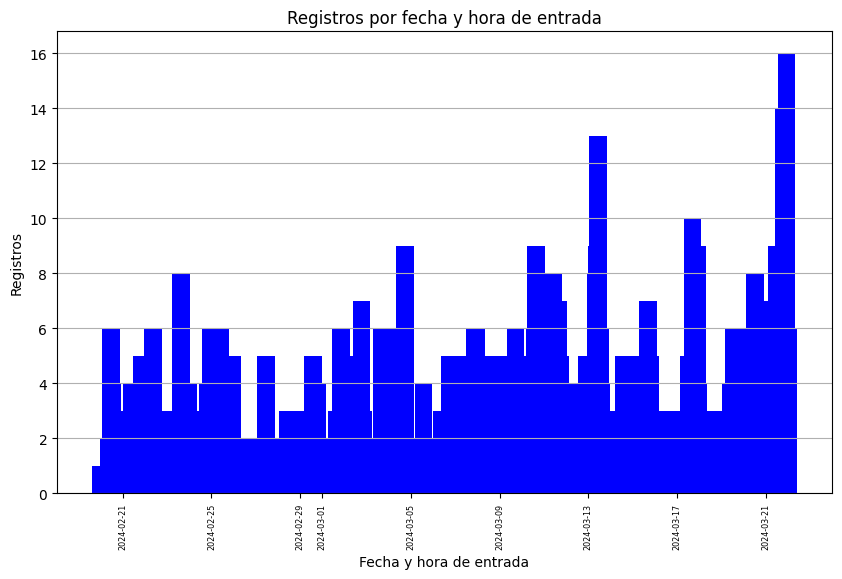

In [20]:
# Crear gráfica de registros por fecha y hora de entrada
plt.figure(figsize=(10, 6))
conteo_fechas = dfFechasProcesadas['fecha_formateada'].value_counts().sort_index()
fechas_ordenadas = conteo_fechas.index
frecuencias = conteo_fechas.values

plt.bar(fechas_ordenadas, frecuencias, color='blue')
plt.title('Registros por fecha y hora de entrada')
plt.xlabel('Fecha y hora de entrada')
plt.ylabel('Registros')
plt.xticks(rotation=90, fontsize= 'xx-small')
plt.grid(axis='y')
plt.show()

---

## 3. Relación entre Preguntas Depuradas (Población) y Preguntas Descartadas

**Proporción entre preguntas elminadas y depuradas** de población inicial total de 24,000 preguntas recibidas:
* 21,219 preguntas en población depurada
* 1,117 preguntas descartadas por uso de términos proscritos
* 1,664 preguntas descartadas por repeticiones exactas


In [21]:
# Verificar número de filas y columnas en tabla de preguntas eliminadas
dfPreguntasDescartadas.shape

(2781, 13)

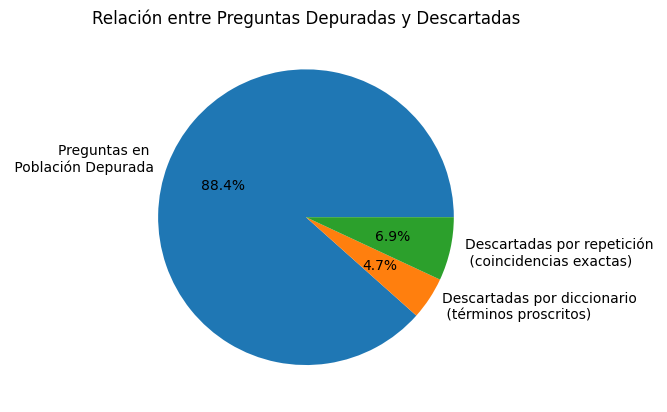

In [22]:
# Crear gráfica de pastel con relación entre preguntas en población depurada y eliminadas
pieDistEliminadas = {
    "Preguntas en \n Población Depurada": len(dfPoblacion21219),
    "Descartadas por diccionario \n (términos proscritos)": len(dfPreguntasDescartadas[dfPreguntasDescartadas["razon_eliminacion"] != "Redacción repetida respecto a otra pregunta"]),
    "Descartadas por repetición \n (coincidencias exactas)": len(dfPreguntasDescartadas[dfPreguntasDescartadas["razon_eliminacion"] == "Redacción repetida respecto a otra pregunta"])
}

valores = list(pieDistEliminadas.values())
etiquetas = list(pieDistEliminadas.keys())

plt.pie(valores, labels=etiquetas, autopct='%1.1f%%', colors=plt.rcParams['axes.prop_cycle'].by_key()['color'], center=(0.5, 0.5))
plt.title('Relación entre Preguntas Depuradas y Descartadas')
plt.show()

**Preguntas eliminadas por diccionarios según su razonamiento** (categoría de térmninos proscritos):

C:\Users\signalab\AppData\Local\Temp\ipykernel_17492\189196395.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')


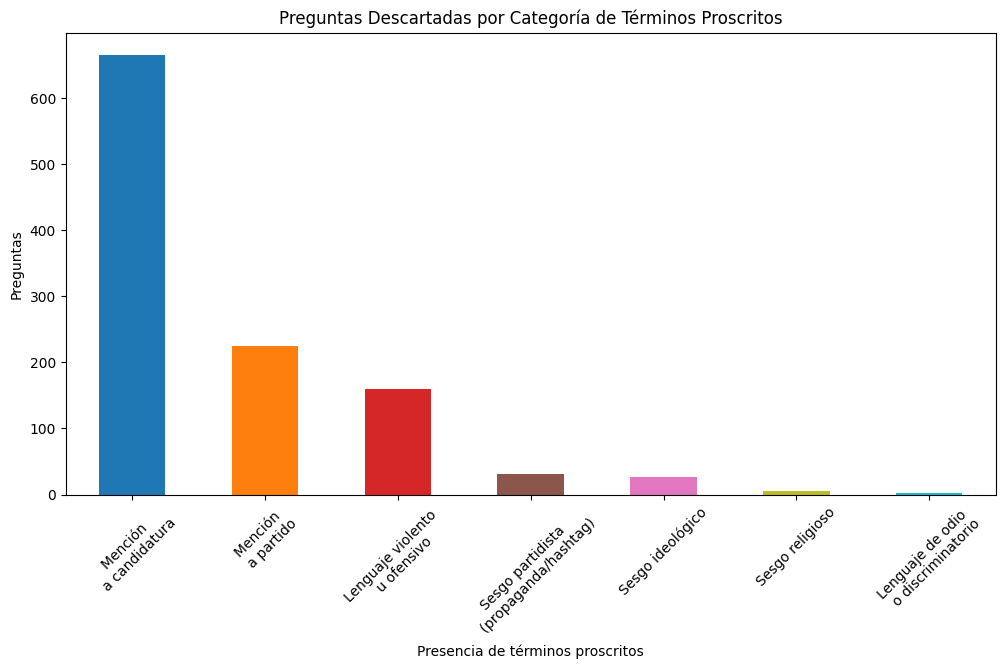

In [23]:
# Contar frecuencias de razonamiento de eliminación por diccionario (términos proscritos)
dictEtiquetasRazones = {
    "candidatura":"Mención \n a candidatura",
    "partido": "Mención \n a partido",
    "ofensa-violencia": "Lenguaje violento \n u ofensivo",
    "hashtag-propaganda": "Sesgo partidista \n (propaganda/hashtag)",
    "sesgo-ideologico": "Sesgo ideológico",
    "sesgo-religioso": "Sesgo religioso",
    "odio-discriminacion": "Lenguaje de odio \n o discriminatorio"
}

conteo_razones = dfPreguntasDescartadas[dfPreguntasDescartadas['razon_eliminacion'] != "Redacción repetida respecto a otra pregunta"]['razon_eliminacion'].value_counts()
conteo_razones.index = conteo_razones.index.map(lambda x: dictEtiquetasRazones[x.split()[-1]])

# Crear gráfica de barras con preguntas eliminadas por diccionarios según su razonamiento
cmap = plt.cm.get_cmap('tab10')
colors = cmap(np.linspace(0, 1, len(conteo_razones)))

ax = conteo_razones.plot(kind='bar', figsize=(12, 6), color=colors, rot=45)
ax.set_title('Preguntas Descartadas por Categoría de Términos Proscritos')
ax.set_xlabel('Presencia de términos proscritos')
ax.set_ylabel('Preguntas')

plt.show()

In [24]:
# Imprimir listado de frecuencias de preguntas descartadas por categoría en diccionario de términos proscritos
conteo_razones

razon_eliminacion
Mención \n a candidatura                    666
Mención \n a partido                        225
Lenguaje violento \n u ofensivo             160
Sesgo partidista \n (propaganda/hashtag)     31
Sesgo ideológico                             27
Sesgo religioso                               6
Lenguaje de odio \n o discriminatorio         2
Name: count, dtype: int64

---

## 4. Análisis Exploratorio de Datos (A.E.D.) de Población de Preguntas Depuradas

In [4]:
# Verificar cantidad de filas y columnas en tabla de población de preguntas depuradas
dfPoblacion21219.shape

(21219, 12)

Asignar **paleta de colores por tema para gráficas:**

In [105]:
# Enlistar temas y códigos de color
themes = ["Combate a la corrupción", "Educación", "No discriminación y grupos vulnerables", "Salud", "Transparencia", "Violencia en contra de las mujeres"]
topic_color_palette = ["#c1883f", "#7878cd", "#7aa444", "#c45ca2", "#4aad92", "#cc554f"]

# Emparejar cada tema con cada color
topic_color_dict = dict(zip(themes, topic_color_palette))

### Preguntas por región en población depurada:

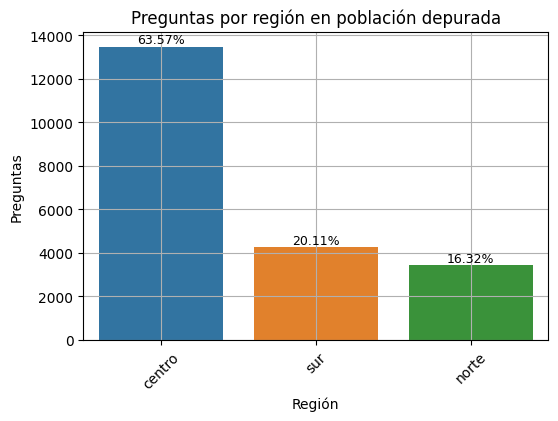

In [6]:
# Contar preguntas y calcular porcentajes por región
total_entries = len(dfPoblacion21219)
counts = dfPoblacion21219['region'].value_counts()
percentage = counts / total_entries * 100

# Crear gráfica de barras de preguntas por región en población depurada
column = 'region'
figsize = (6, 4)
fig, ax = plt.subplots(figsize=figsize)
sns.barplot(x=counts.index, y=counts.values, order=counts.index, hue=counts.index, ax=ax)
plt.title(f'Preguntas por región en población depurada')
plt.ylabel('Preguntas')
plt.xlabel('Región')
plt.xticks(rotation=45)
plt.grid(True)

# Añadir los valores de porcentaje en las barras
for index, value in enumerate(counts.values):
    ax.annotate(f'{percentage.iloc[index]:.2f}%', xy=(index, value), ha='center', va='bottom', fontsize=9)

plt.show()


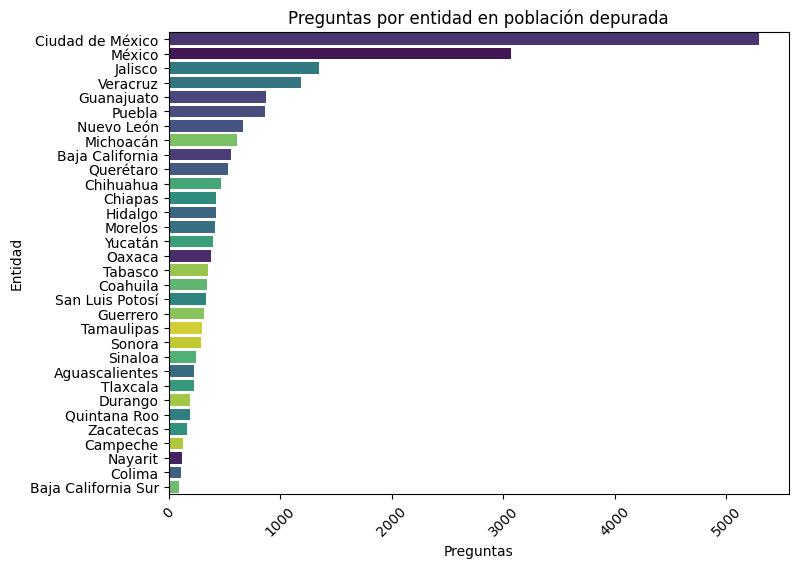

In [7]:
# Crear gráfica de barras de preguntas por entidad en población depurada
column = 'entidad'
figsize = (8,6)
orden = dfPoblacion21219[column].value_counts().index
plt.figure(figsize=figsize)
sns.countplot(data=dfPoblacion21219, y=column, hue=column, palette='viridis', order=orden, legend=False)
plt.title(f'Preguntas por entidad en población depurada')
plt.xlabel('Preguntas')
plt.ylabel('Entidad')
plt.xticks(rotation=45)
plt.show()

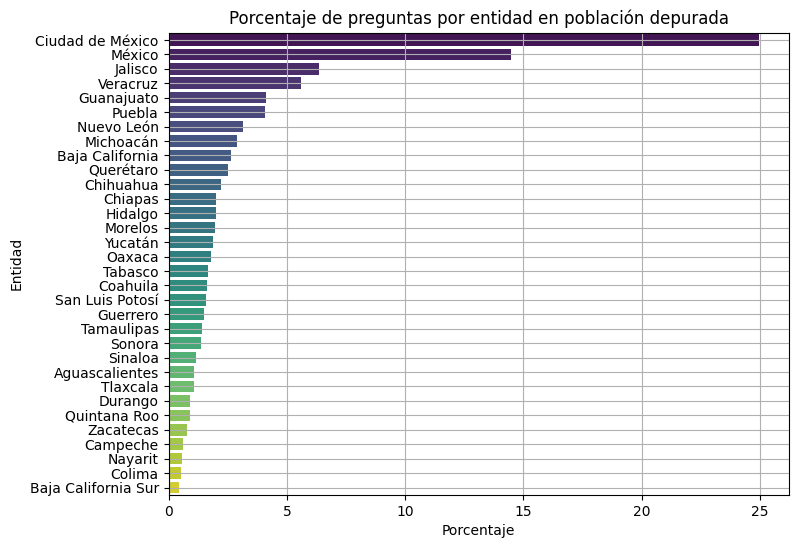

In [15]:
column = 'entidad'
figsize = (8,6)

# Calcular los porcentajes
porcentajes = dfPoblacion21219[column].value_counts(normalize=True) * 100
orden = porcentajes.index

plt.figure(figsize=figsize)
sns.barplot(x=porcentajes, y=orden, hue=orden, palette='viridis', legend=False)
plt.title('Porcentaje de preguntas por entidad en población depurada')
plt.xlabel('Porcentaje')
plt.ylabel('Entidad')
plt.xticks()
plt.grid()
plt.show()

### Preguntas por tema en población depurada:

In [128]:
topic_color_palette

['blue', 'green', 'orange', 'red', 'purple', 'cyan']

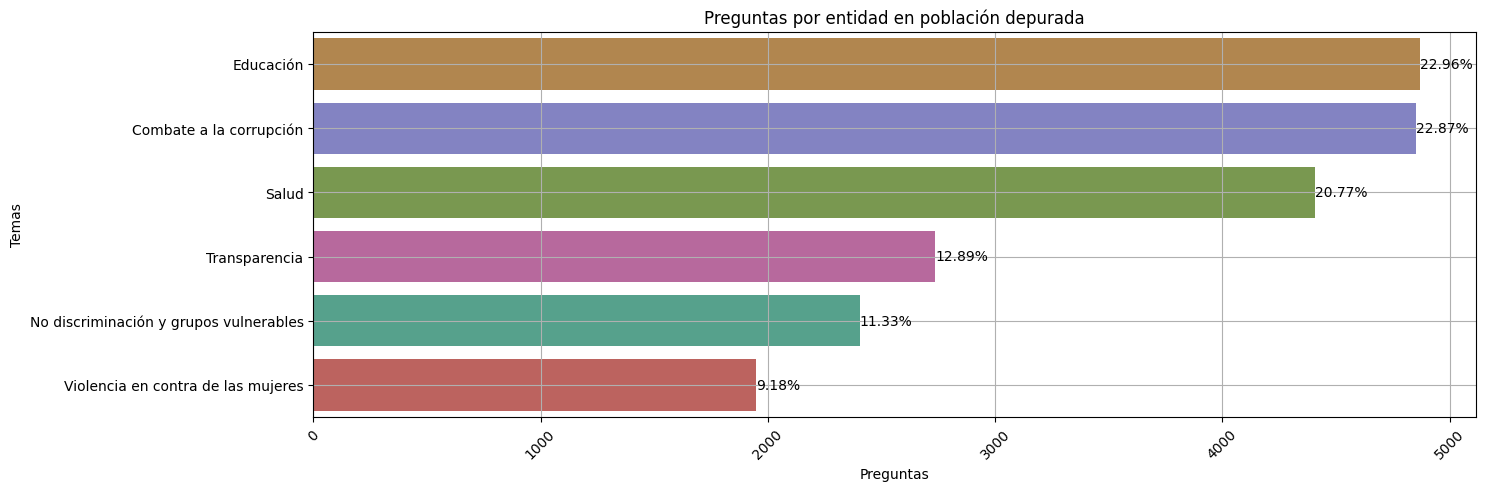

In [29]:
# Contar preguntas por cada tema y calcular porcentajes
total_entries = len(dfPoblacion21219)
counts = dfPoblacion21219['tema'].value_counts()
percentage = counts / total_entries * 100

sns.set_palette(topic_color_palette)

# Crear gráfica con de barras con preguntas de población depurada por tema
column = 'tema'
figsize = (15, 5)
plt.figure(figsize=figsize)
sns.barplot(x=counts.values, y=counts.index, order=counts.index, dodge=False, hue=counts.index, legend=False)
plt.title('Preguntas por entidad en población depurada')
plt.xlabel('Preguntas')
plt.ylabel('Temas')
plt.xticks(rotation=45)
plt.grid(True)

# Añadir los valores de porcentaje en las barras
for i, val in enumerate(percentage):
    plt.text(counts.values[i], i, f'{val:.2f}%', fontsize=10, va='center')

plt.show()


### Preguntas por tema y por región en población depurada:

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\3255078168.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\3255078168.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\3255078168.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



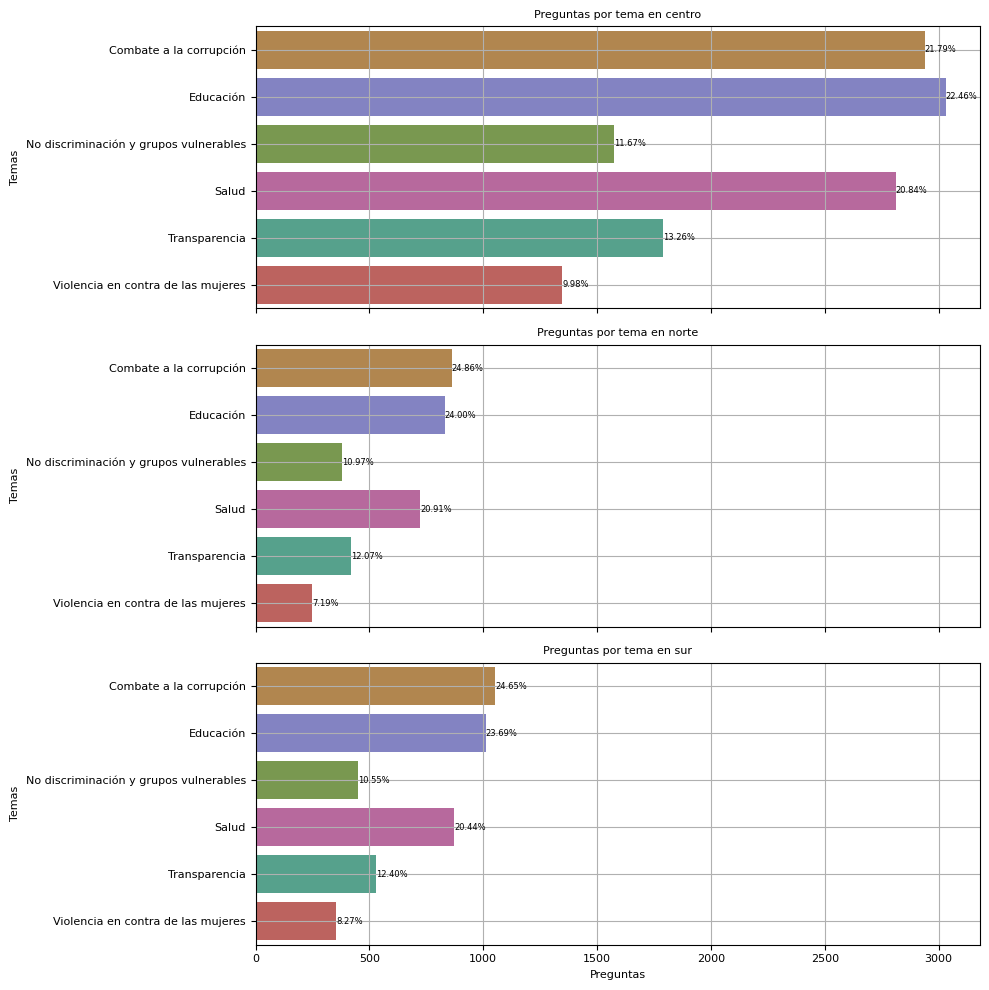

In [118]:
# Agrupar por región y tema, y calcular conteo y porcentaje
grouped_df = dfPoblacion21219.groupby(['region', 'tema']).size().reset_index(name='count')
grouped_df['percentage'] = grouped_df.groupby('region')['count'].transform(lambda x: x / x.sum() * 100)

sns.set_palette(topic_color_palette)

# Crear gráficos agrupados por región
regions = grouped_df['region'].unique()
num_regions = len(regions)

fig, axes = plt.subplots(num_regions, 1, figsize=(10, 10), sharex=True)

for i, region in enumerate(regions):
    region_data = grouped_df[grouped_df['region'] == region]
    sns.barplot(ax=axes[i], x='count', y='tema', data=region_data, hue='tema', dodge=False)
    axes[i].set_title(f'Preguntas por tema en {region}', fontsize=8)
    axes[i].set_xlabel('Preguntas', fontsize=8)  # Modificar tamaño de la etiqueta en el eje x
    axes[i].set_ylabel('Temas', fontsize=8)  # Modificar tamaño de la etiqueta en el eje y
    axes[i].grid(True)
    
    # Establecer los nombres de Hue como etiquetas en el eje y
    axes[i].set_yticklabels(region_data['tema'], fontsize=8)
    
    # Añadir porcentajes en las barras con tamaño de fuente reducido
    for j, val in enumerate(region_data['percentage']):
        axes[i].text(region_data['count'].values[j], j, f'{val:.2f}%', fontsize=6, va='center')  # Modificar tamaño de la fuente en los textos
    
    # Reducir tamaño de los números en los ejes x e y
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


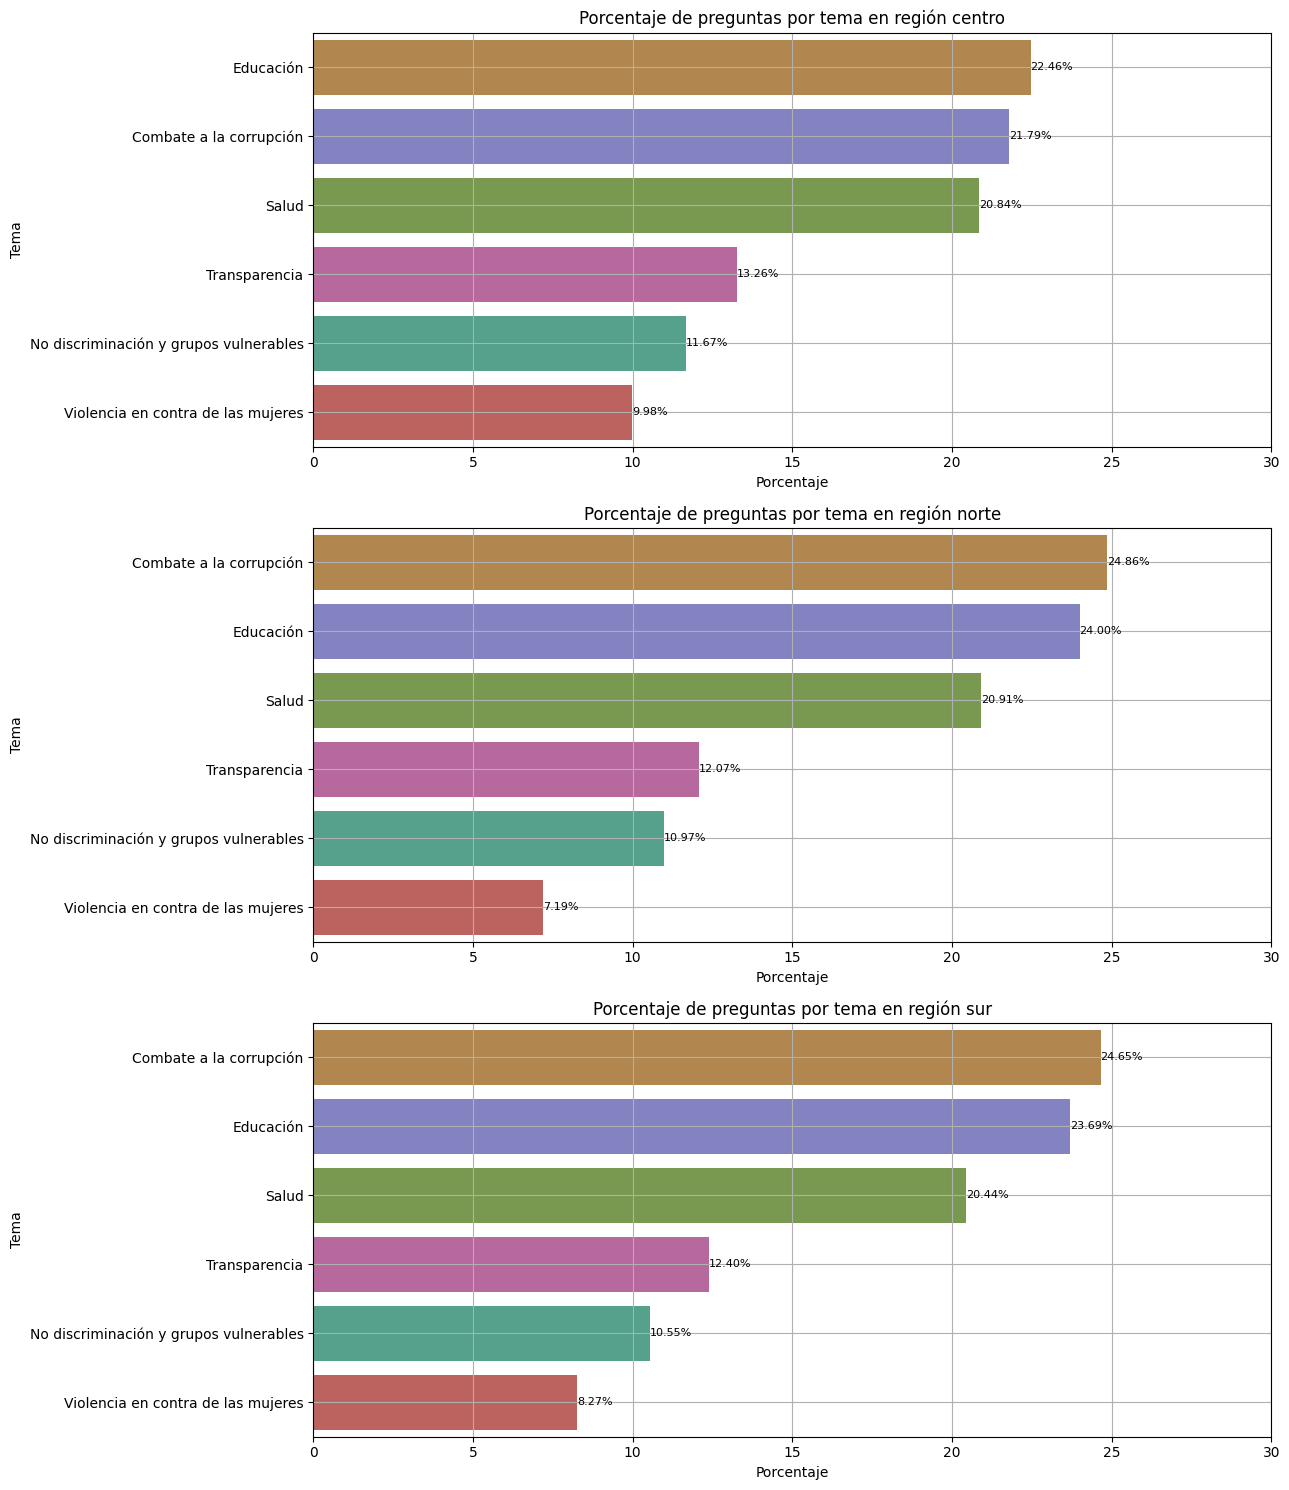

In [231]:
# Crear gráficas con porcentajes de preguntas de población depurada por tema y región
total_entries_region = dfPoblacion21219.groupby('region').size()
counts_region = dfPoblacion21219.groupby(['region', 'tema']).size().unstack(fill_value=0)
percentage_region = counts_region.div(total_entries_region, axis=0) * 100

# Crear gráficas para cada región
fig, axes = plt.subplots(nrows=len(percentage_region), figsize=(13, 5 * len(percentage_region)))
fig.subplots_adjust(hspace=0.5)

for i, (region, data) in enumerate(percentage_region.iterrows()):
    # Ordenar categorías
    sorted_data = data.sort_values(ascending=False)
    ax = sns.barplot(x=sorted_data.values, y=sorted_data.index, hue=sorted_data.index, ax=axes[i], legend=False, palette=topic_color_palette)
    ax.set_title(f'Porcentaje de preguntas por tema en región {region}')
    ax.set_xlabel('Porcentaje')
    ax.set_ylabel('Tema')
    ax.grid(True)

    # Añadir etiquetas con porcentajes
    for j, val in enumerate(sorted_data.values):
        ax.text(val, j, f'{val:.2f}%', fontsize=8, va='center')

    # Ajustar eje horizontal a rango fijo de 0 a 30%
    ax.set_xlim(0, 30)

plt.tight_layout()
plt.show()

In [32]:
# Agrupar por región y tema y contar el número de ocurrencias
counts_region = dfPoblacion21219.groupby(['region', 'tema']).size().unstack(fill_value=0)

# Calcular el total por región
counts_region['Total por region'] = counts_region.sum(axis=1)

# Calcular el total por tema
counts_region.loc['Total por tema'] = counts_region.sum(axis=0)

# Mostrar el DataFrame actualizado
counts_region


tema,Combate a la corrupción,Educación,No discriminación y grupos vulnerables,Salud,Transparencia,Violencia en contra de las mujeres,Total por region
region,,,,,,,
centro,2939,3030,1574,2811,1789,1346,13489
norte,861,831,380,724,418,249,3463
sur,1052,1011,450,872,529,353,4267
Total por tema,4852,4872,2404,4407,2736,1948,21219


### Preguntas por edad en población depurada:

In [30]:
# Agregar columna con valor de rango de edad correspondiente a cada pregunta (cada 5 años)
bins = [13, 18, 23, 28, 33, 38, 43, 48, 53, 58, 63, 68,73,78,83,88,93,99]
labels = ['13-17', '18-22', '23-27', '28-32', '33-37', '38-42','43-47','48-52','53-57','58-62','63-67','68-72','73-77','78-82','83-87','88-92','93-99']

dfPoblacion21219['rango_edad_c5'] = pd.cut(dfPoblacion21219['edad'], bins=bins, labels=labels, right=False)

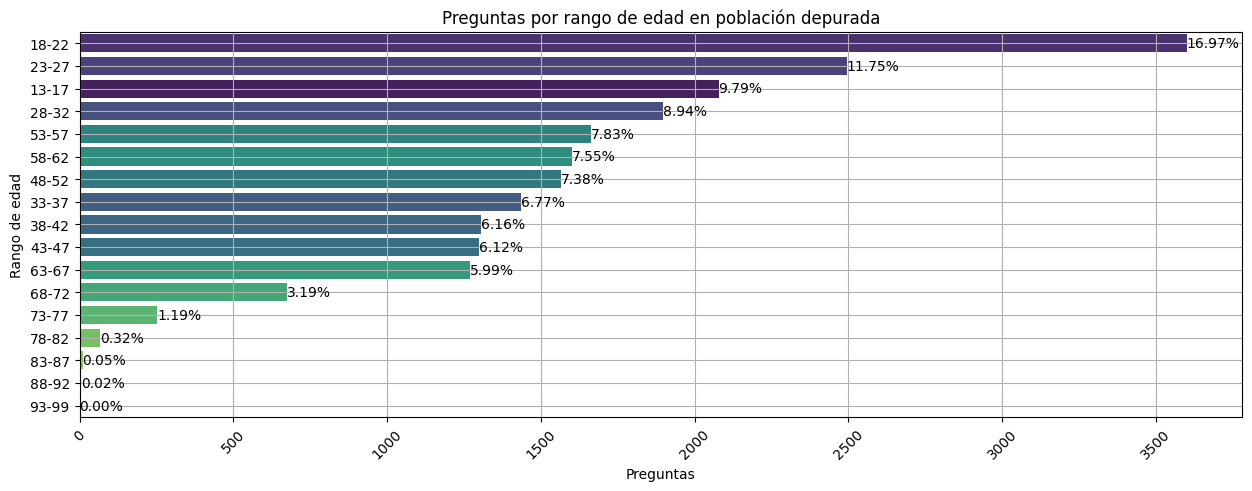

In [34]:
# Calcula el porcentaje de cada tema
total_entries = len(dfPoblacion21219)
counts = dfPoblacion21219['rango_edad_c5'].value_counts()
percentage = counts / total_entries * 100

# Crear gráfica de barras con preguntas por rango de edadcolumn = 'rango_edad_c5'
figsize = (15, 5)
plt.figure(figsize=figsize)
sns.barplot(x=counts.values, y=counts.index, order=counts.index, palette='viridis', dodge=False, hue=counts.index, legend=False)
plt.title(f'Preguntas por rango de edad en población depurada')
plt.xlabel('Preguntas')
plt.ylabel('Rango de edad')
plt.xticks(rotation=45)
plt.grid(True)

# Añadir los valores de porcentaje en las barras
for i, val in enumerate(percentage):
    plt.text(counts.values[i], i, f'{val:.2f}%', fontsize=10, va='center')

plt.show()

### Preguntas por edad y región en población depurada:

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\2671660644.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\2671660644.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\2671660644.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



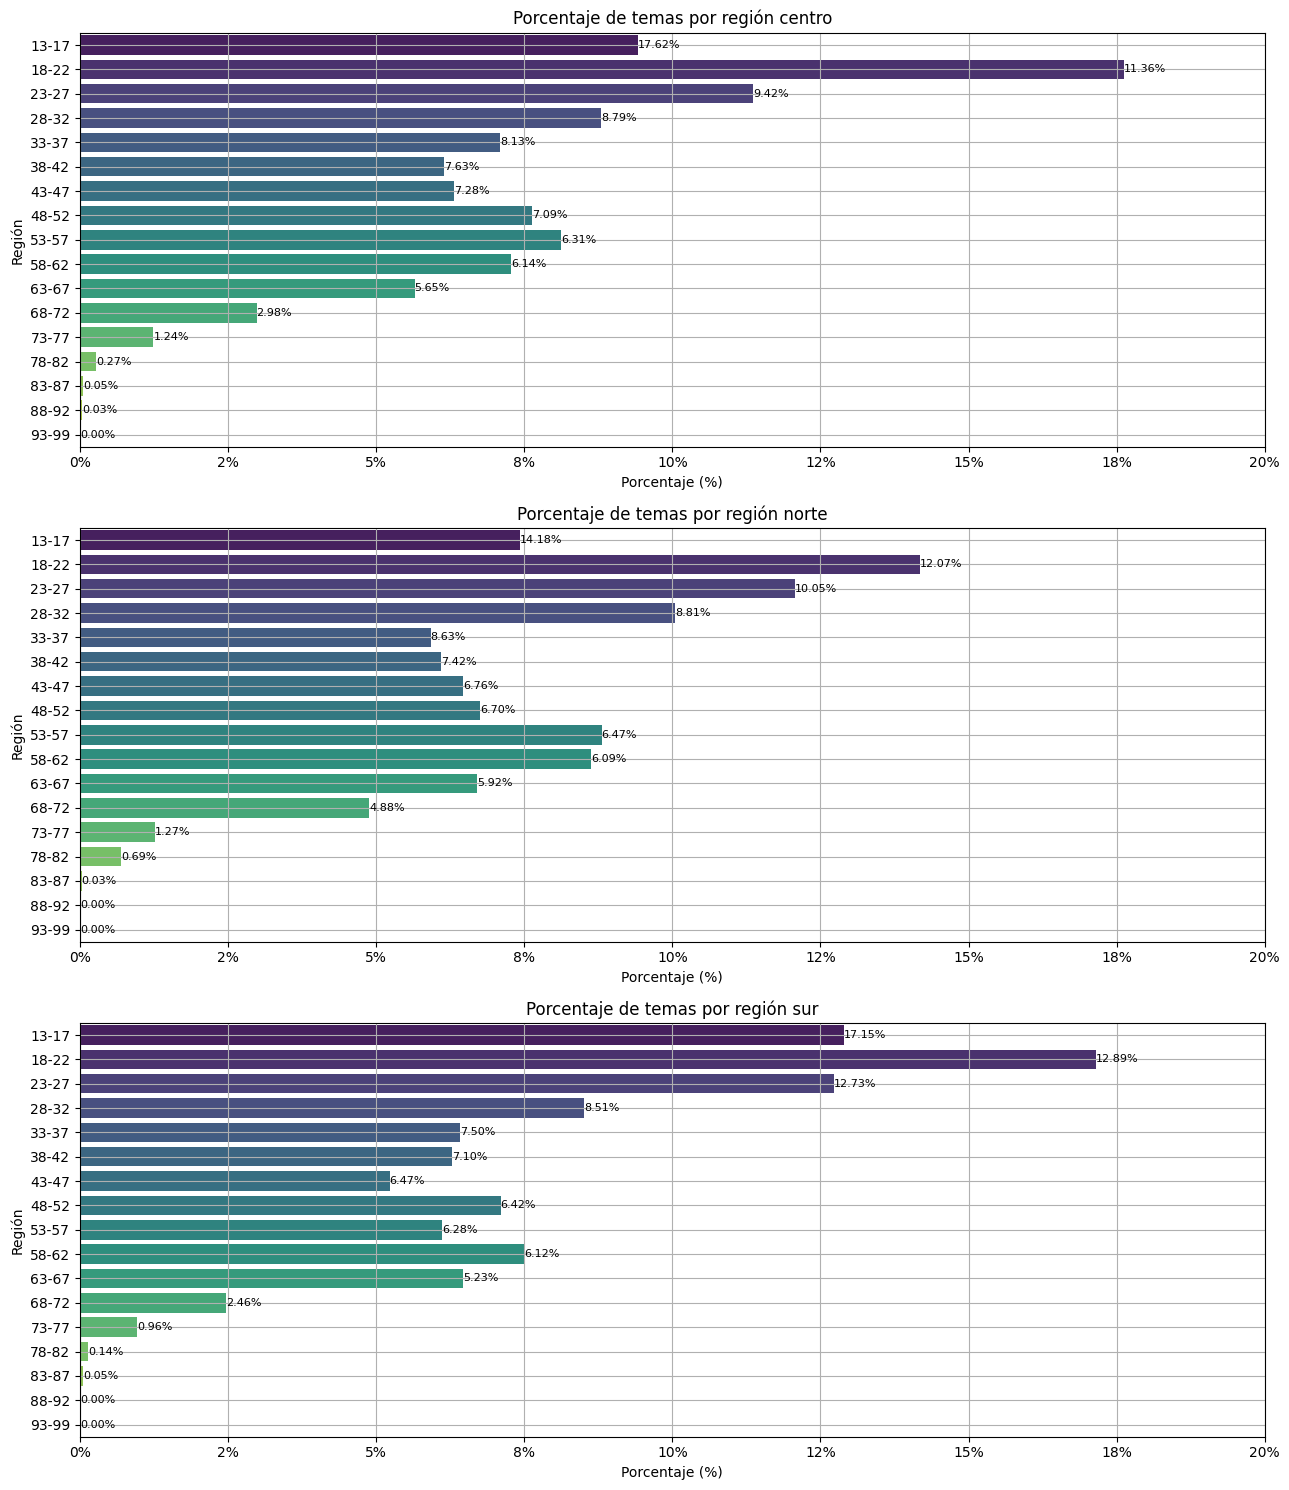

In [239]:
# Crear gráficas de barras para cada región
fig, axes = plt.subplots(nrows=len(percentage_region), figsize=(13, 5 * len(percentage_region)))
fig.subplots_adjust(hspace=0.5)

for i, (region, data) in enumerate(percentage_region.iterrows()):
    sorted_data = data.sort_values(ascending=False)
    ax = sns.barplot(x=sorted_data.values, y=sorted_data.index, hue=sorted_data.index, ax=axes[i], legend=False, palette="viridis")
    ax.set_title(f'Porcentaje de temas por región {region}')
    ax.set_xlabel('Porcentaje (%)') 
    ax.set_ylabel('Región')
    ax.grid(True)

    # Ajustar el eje horizontal a un rango fijo de 0 a 20%
    ax.set_xlim(0, 20)
    
    x_ticks = ax.get_xticks()
    ax.set_xticklabels([f'{tick:.0f}%' for tick in x_ticks])

    for bar, val in zip(ax.patches, sorted_data.values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{val:.2f}%', fontsize=8, ha='left', va='center')

plt.tight_layout()
plt.show()


### Preguntas por edad y tema en población depurada:

In [180]:
topic_color_palette = ["#c1883f", "#7878cd", "#7aa444", "#c45ca2", "#4aad92", "#cc554f"]
sns.set_palette(topic_color_palette)

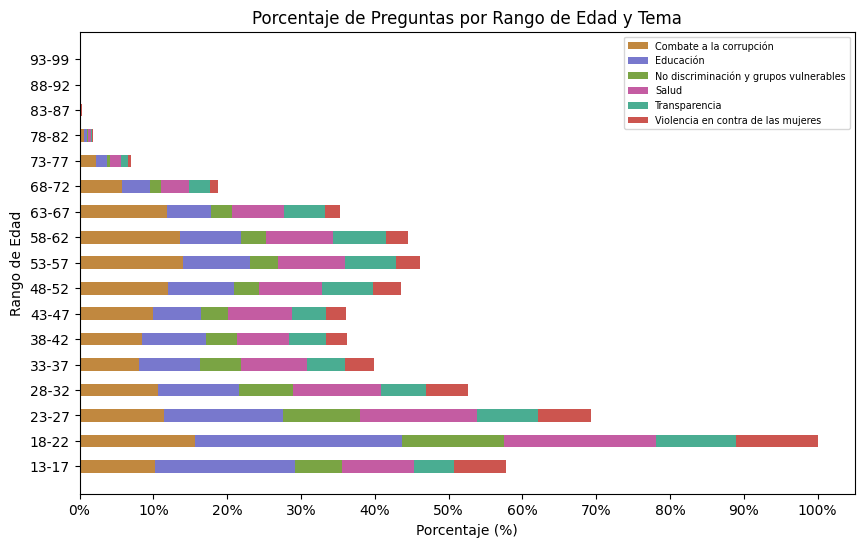

In [235]:
topic_color_palette = ["#c1883f", "#7878cd", "#7aa444", "#c45ca2", "#4aad92", "#cc554f"]

# Obtener el total de preguntas por cada rango de edad
total_preguntas_por_edad = pivot_df.sum(axis=1)

# Calcular los porcentajes para cada tema en base al grupo de edad con más preguntas
porcentajes_por_tema = (pivot_df.T / total_preguntas_por_edad.max(axis=0) * 100).T

fig, ax = plt.subplots(figsize=(10, 6))
barWidth = 0.5


for i, col in enumerate(porcentajes_por_tema.columns):
    ax.barh(porcentajes_por_tema.index, porcentajes_por_tema[col], height=barWidth, 
            left=np.sum(porcentajes_por_tema.iloc[:, :i], axis=1), label=col, color=topic_color_palette[i % len(topic_color_palette)])

# Etiquetas de porcentaje en el eje X
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xticklabels([f'{int(x)}%' for x in np.arange(0, 101, 10)])

plt.xlabel('Porcentaje (%)')
plt.ylabel('Rango de Edad')
plt.title('Porcentaje de Preguntas por Rango de Edad y Tema')
plt.yticks(rotation=0)
plt.legend(fontsize='x-small', loc='upper right')
plt.show()


In [211]:
# Imprimir tabla con frecuencias por tema y rango de edad
pivot_df

tema,Combate a la corrupción,Educación,No discriminación y grupos vulnerables,Salud,Transparencia,Violencia en contra de las mujeres
rango_edad_c5,,,,,,
13-17,370,679,229,351,197,252
18-22,561,1012,496,745,387,399
23-27,414,576,377,574,293,260
28-32,384,394,265,425,223,206
33-37,290,300,200,318,187,141
38-42,307,309,152,255,179,105
43-47,358,233,132,311,170,94
48-52,433,320,121,311,247,134
53-57,506,326,134,327,250,119


In [207]:
# Calcula la suma total por rango de edad
suma_total_por_rango_edad = pivot_df.sum(axis=1)

# Divide cada valor en la tabla por su respectiva suma total para obtener los porcentajes
pivot_df_porcentaje = pivot_df.div(suma_total_por_rango_edad, axis=0) * 100

# Imprimir tabla con porcentajes por tema y rango de edad
pivot_df_porcentaje

tema,Combate a la corrupción,Educación,No discriminación y grupos vulnerables,Salud,Transparencia,Violencia en contra de las mujeres
rango_edad_c5,,,,,,
13-17,17.805582,32.675650,11.020212,16.891242,9.480269,12.127045
18-22,15.583333,28.111111,13.777778,20.694444,10.750000,11.083333
23-27,16.599840,23.095429,15.116279,23.015237,11.748196,10.425020
28-32,20.242488,20.769636,13.969425,22.403795,11.755403,10.859251
33-37,20.194986,20.891365,13.927577,22.144847,13.022284,9.818942
38-42,23.488906,23.641928,11.629686,19.510329,13.695486,8.033665
43-47,27.580894,17.950693,10.169492,23.959938,13.097072,7.241911
48-52,27.650064,20.434227,7.726692,19.859515,15.772669,8.556833
53-57,30.445247,19.614922,8.062575,19.675090,15.042118,7.160048


In [99]:
# Crear mapa de árbol (treemap) con preguntas por tema y rango de edad

data_for_treemap = dfPoblacion21219.copy()
data_for_treemap = data_for_treemap.dropna(subset=['tema', 'rango_edad_c5'])

fig = px.treemap(data_for_treemap,
                 path=['tema', 'rango_edad_c5'],
                 title='Preguntas por rango de edad y tema en población depurada',
                 color='tema',
                 color_discrete_map=topic_color_dict)
fig.update_traces(textinfo="label+percent parent")
fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))

fig.show()

### Preguntas por género en población depurada:

C:\Users\signalab\AppData\Local\Temp\ipykernel_17492\2518385750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Nulos (vacíos)', 'Válidos (respondidos)'], y=[cantidad_nulos, cantidad_no_nulos], palette=['red', 'green'])


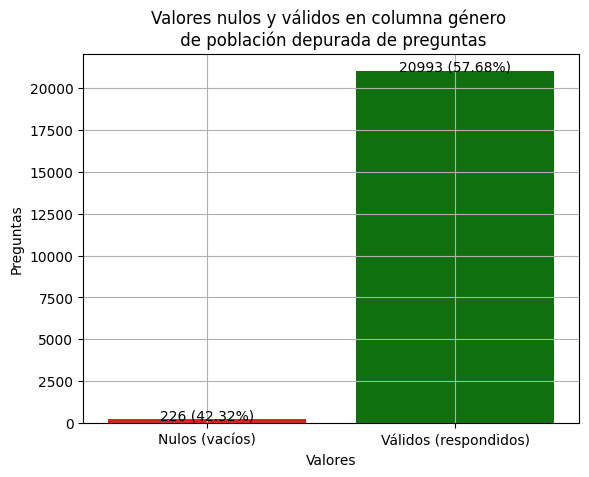

In [37]:
# Contar preguntas con valores nulos (vacías) y válidos (respondidas) en campo (opcional) género
cantidad_nulos = dfPoblacion21219['genero'].isnull().sum()
cantidad_no_nulos = dfPoblacion21219['genero'].notnull().sum()

# Crear gráfica de barras con valores nulos y válidos
sns.barplot(x=['Nulos (vacíos)', 'Válidos (respondidos)'], y=[cantidad_nulos, cantidad_no_nulos], palette=['red', 'green'])
plt.xlabel('Valores')
plt.ylabel('Preguntas')
plt.title('Valores nulos y válidos en columna género \n de población depurada de preguntas')

#agregar los porcentajes
for i, valor in enumerate([cantidad_nulos, cantidad_no_nulos]):
    if i == 0:
        plt.text(i, valor + 0.5, f'{valor} ({pcntg_nulos:.2f}%)', ha='center')
    else:
        plt.text(i, valor + 0.5, f'{valor} ({pcntg_no_nulos:.2f}%)', ha='center')

plt.grid()
plt.show()

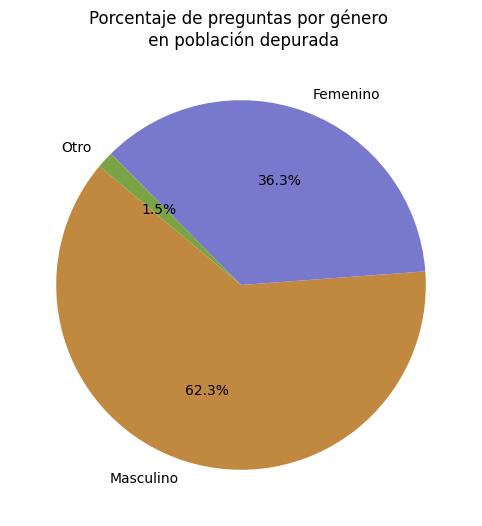

In [38]:
# Crear gráfica con porcentaje de preguntas por género en población depurada
column='genero'
figsize=(8,6)
plt.figure(figsize=(8, 6))
dfPoblacion21219[column].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title(f'Porcentaje de preguntas por género \n en población depurada')
plt.ylabel('')
plt.show()

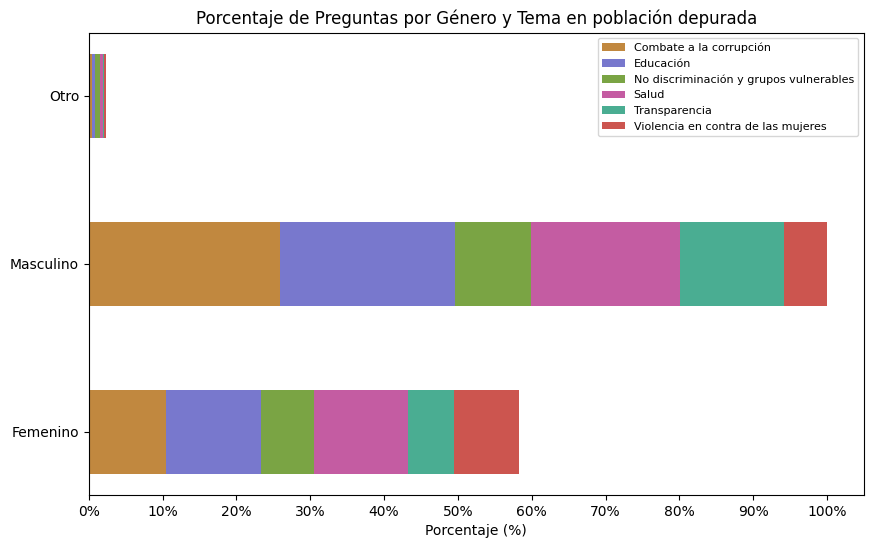

In [171]:
# Obtener el total de preguntas por cada género
total_preguntas_por_genero = pivot_df_genero.sum(axis=1)

# Calcular los porcentajes para cada tema en base al género con más preguntas
porcentajes_por_tema_genero = (pivot_df_genero.T / total_preguntas_por_genero.max(axis=0) * 100).T

fig, ax = plt.subplots(figsize=(10, 6))
barWidth = 0.5

for i, col in enumerate(porcentajes_por_tema_genero.columns):
    ax.barh(porcentajes_por_tema_genero.index, porcentajes_por_tema_genero[col], height=barWidth, 
            left=np.sum(porcentajes_por_tema_genero.iloc[:, :i], axis=1), label=col, color=topic_color_palette[i % len(topic_color_palette)])

# Etiquetas de porcentaje en el eje X
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xticklabels([f'{int(x)}%' for x in np.arange(0, 101, 10)])

plt.xlabel('Porcentaje (%)')
plt.title('Porcentaje de Preguntas por Género y Tema en población depurada')
plt.yticks(rotation=0)
plt.legend(fontsize='8', loc='upper right')
plt.show()


In [209]:
# Imprimir tabla con frecuencias de preguntas por género y tema
pivot_df_genero

tema,Combate a la corrupción,Educación,No discriminación y grupos vulnerables,Salud,Transparencia,Violencia en contra de las mujeres
genero,,,,,,
Femenino,1368,1674,947,1661,816,1146
Masculino,3384,3110,1338,2645,1846,753
Otro,55,50,99,41,30,30


In [208]:
# Imprimir tabla con porcentajes de preguntas por género y tema
pivot_df_genero_porcentaje = pivot_df_genero.div(pivot_df_genero.sum(axis=1), axis=0) * 100
pivot_df_genero_porcentaje

tema,Combate a la corrupción,Educación,No discriminación y grupos vulnerables,Salud,Transparencia,Violencia en contra de las mujeres
genero,,,,,,
Femenino,17.971624,21.991592,12.440883,21.820809,10.719916,15.055176
Masculino,25.879474,23.784032,10.232487,20.227898,14.117467,5.758642
Otro,18.032787,16.393443,32.459016,13.442623,9.836066,9.836066


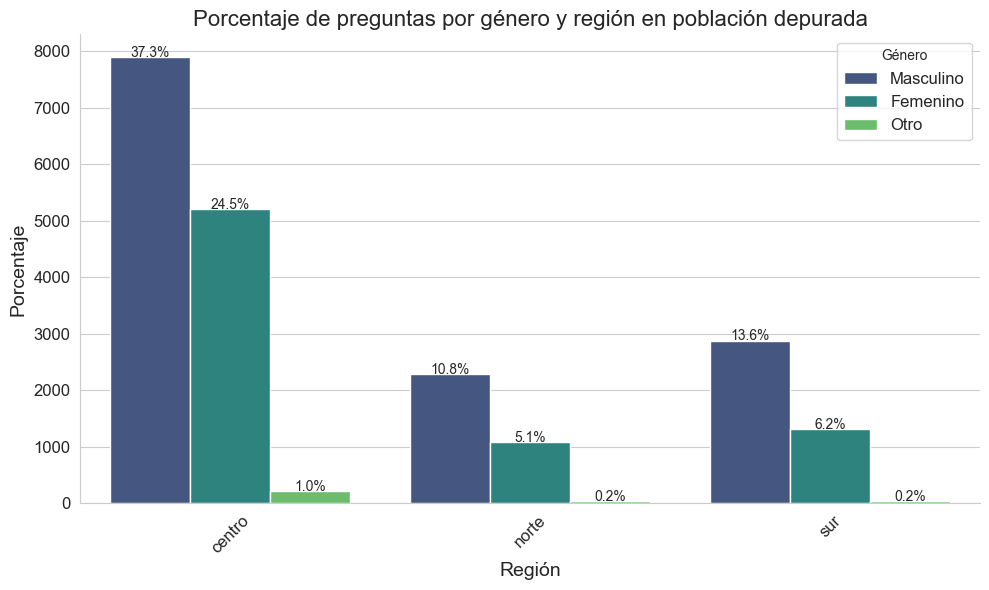

In [39]:
# Crear gráfica de barras comparativa de porcentaje de preguntas por género y por región en población depurada
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=dfPoblacion21219, x='region', hue=column, palette='viridis')

plt.title(f'Porcentaje de preguntas por género y región en población depurada', fontsize=16)
plt.xlabel('Región', fontsize=14)
plt.ylabel('Porcentaje', fontsize=14)

# Añadir etiquetas de porcentaje
total = len(dfPoblacion21219)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 3,
                '{:.1f}%'.format((height / total) * 100),
                ha="center", fontsize=10)

# Eliminar las líneas de la parte superior y derecha del gráfico
sns.despine()

# Mostrar el gráfico
plt.legend(title='Género', fontsize=12) 
plt.xticks(rotation=45, fontsize=12) 
plt.yticks(fontsize=12)  
plt.tight_layout()
plt.show()


### Preguntas por pertenencia a Grupos en Situación de Discriminación en población depurada:

C:\Users\signalab\AppData\Local\Temp\ipykernel_17492\3612291647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Nulos (vacíos)', 'Válidos (respondidos)'], y=[cantidad_nulos, cantidad_no_nulos], palette=['red', 'green'])


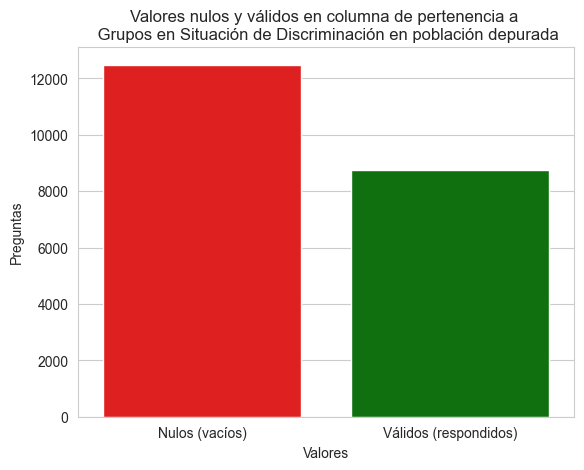

In [40]:
# Contar preguntas con valores nulos (vacías) y válidos (respondidas) en campo (opcional) para indicar Grupo en Situación de Discriminación
cantidad_nulos = dfPoblacion21219['grupos_discriminacion'].isnull().sum()
cantidad_no_nulos = dfPoblacion21219['grupos_discriminacion'].notnull().sum()

# Crear gráfica de barras con valores nulos y válidos
sns.barplot(x=['Nulos (vacíos)', 'Válidos (respondidos)'], y=[cantidad_nulos, cantidad_no_nulos], palette=['red', 'green'])
plt.xlabel('Valores')
plt.ylabel('Preguntas')
plt.title('Valores nulos y válidos en columna de pertenencia a \n Grupos en Situación de Discriminación en población depurada')

# Agregar los porcentajes a etiquetas
for i, valor in enumerate([cantidad_nulos, cantidad_no_nulos]):
    if i == 0:
        plt.text(i, valor + 0.5, f'{valor} ({pcntg_nulos:.2f}%)', ha='center')
    else:
        plt.text(i, valor + 0.5, f'{valor} ({pcntg_no_nulos:.2f}%)', ha='center')

plt.grid()
plt.show()

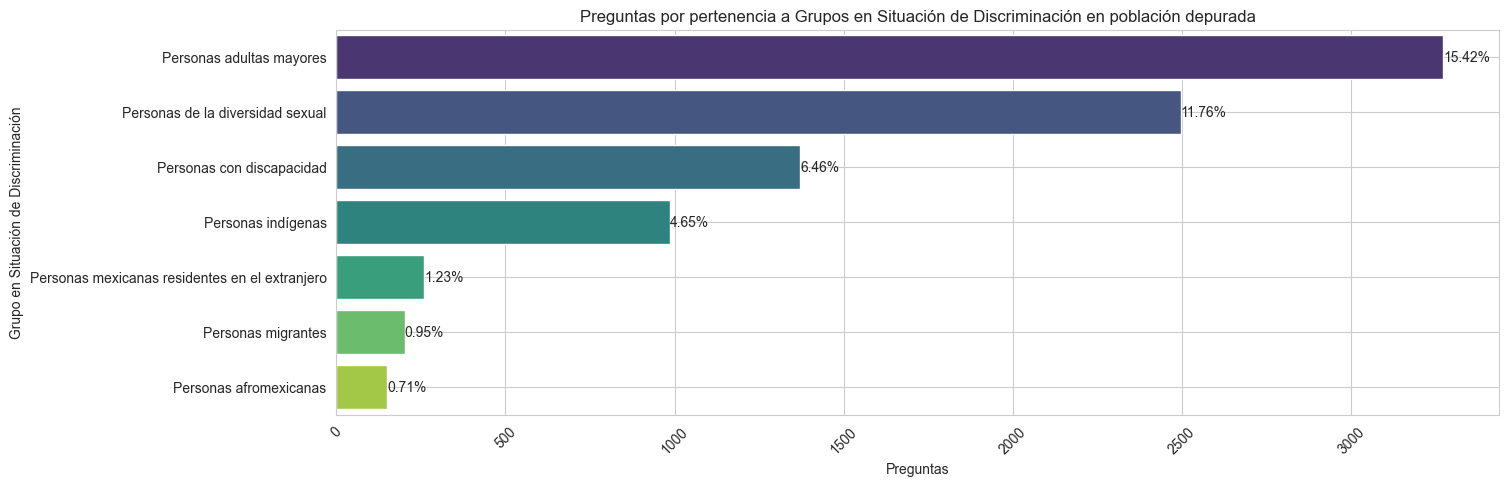

In [42]:
# Contar preguntas por grupo en situación de discriminación y calcular porcentajes
total_entries = len(dfPoblacion21219)
counts = dfPoblacion21219['grupos_discriminacion'].value_counts()
percentage = counts / total_entries * 100

# Crear gráfica de barras por grupos en situación de discriminación
column = 'Grupo Vulnerable'
figsize = (15, 5)
plt.figure(figsize=figsize)
sns.barplot(x=counts.values, y=counts.index, order=counts.index, palette='viridis', dodge=False, hue=counts.index, legend=False)
plt.title(f'Preguntas por pertenencia a Grupos en Situación de Discriminación en población depurada')
plt.xlabel('Preguntas')
plt.ylabel('Grupo en Situación de Discriminación')
plt.xticks(rotation=45)
plt.grid(True)

# Añadir los valores de porcentaje en las barras
for i, val in enumerate(percentage):
    plt.text(counts.values[i], i, f'{val:.2f}%', fontsize=10, va='center')

plt.show()

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\1593481025.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\1593481025.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\signalab\AppData\Local\Temp\ipykernel_12064\1593481025.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



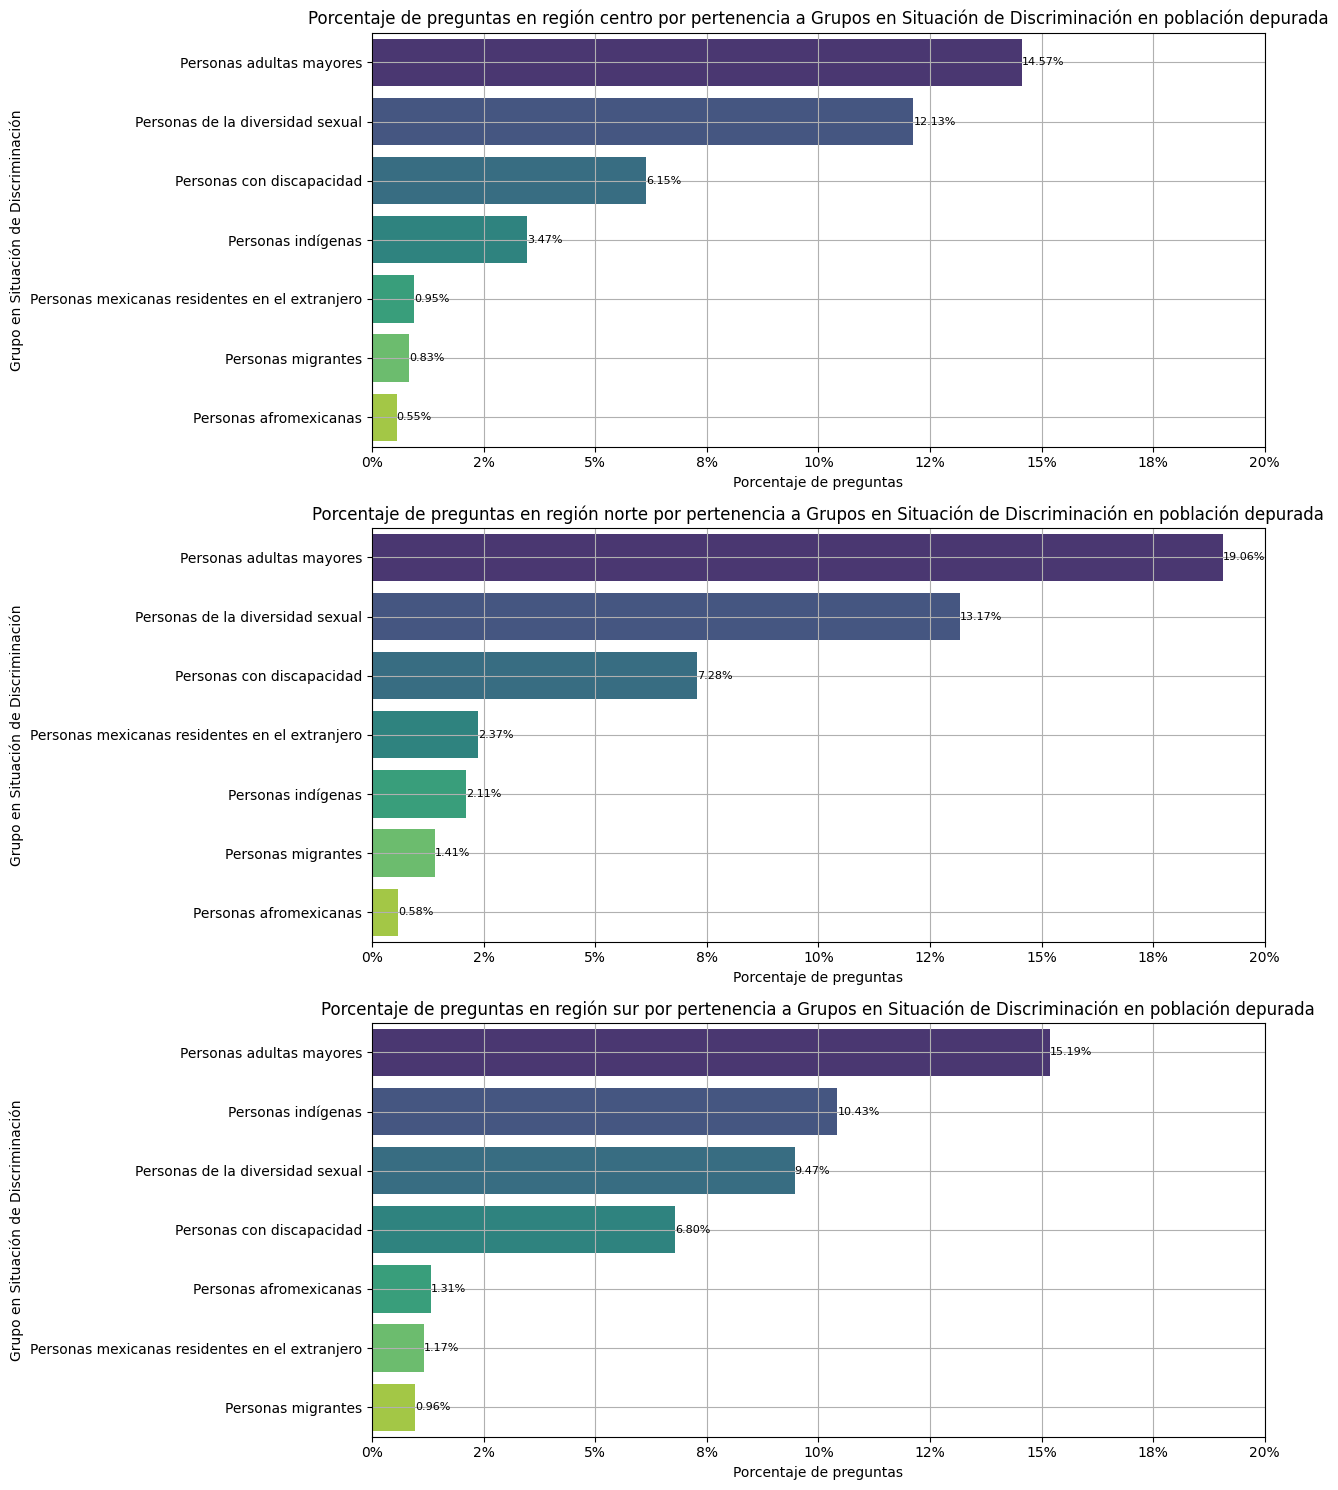

In [240]:
# Contar preguntas por grupo en situación de discriminación y región y calcular porcentajes
total_entries_region = dfPoblacion21219.groupby('region').size()
counts_region = dfPoblacion21219.groupby(['region', 'grupos_discriminacion']).size().unstack(fill_value=0)
percentage_region = counts_region.div(total_entries_region, axis=0) * 100

# Crear gráfica de barras por grupos en situación de discriminación por región
fig, axes = plt.subplots(nrows=len(percentage_region), figsize=(13, 5 * len(percentage_region)))
fig.subplots_adjust(hspace=0.5)

for i, (region, data) in enumerate(percentage_region.iterrows()):
    sorted_data = data.sort_values(ascending=False)
    ax = sns.barplot(x=sorted_data.values, y=sorted_data.index, hue=sorted_data.index, palette='viridis', ax=axes[i], legend=False)
    ax.set_title(f'Porcentaje de preguntas en región {region} por pertenencia a Grupos en Situación de Discriminación en población depurada')
    ax.set_xlabel('Porcentaje de preguntas')
    ax.set_ylabel('Grupo en Situación de Discriminación')
    ax.grid(True)

    # Añadir los valores de porcentaje en las barras
    for j, val in enumerate(sorted_data.values):
        ax.text(val, j, f'{val:.2f}%', fontsize=8, va='center')

    ax.set_xlim(0, 20)
    
    x_ticks = ax.get_xticks()
    ax.set_xticklabels([f'{tick:.0f}%' for tick in x_ticks])

plt.tight_layout()
plt.show()

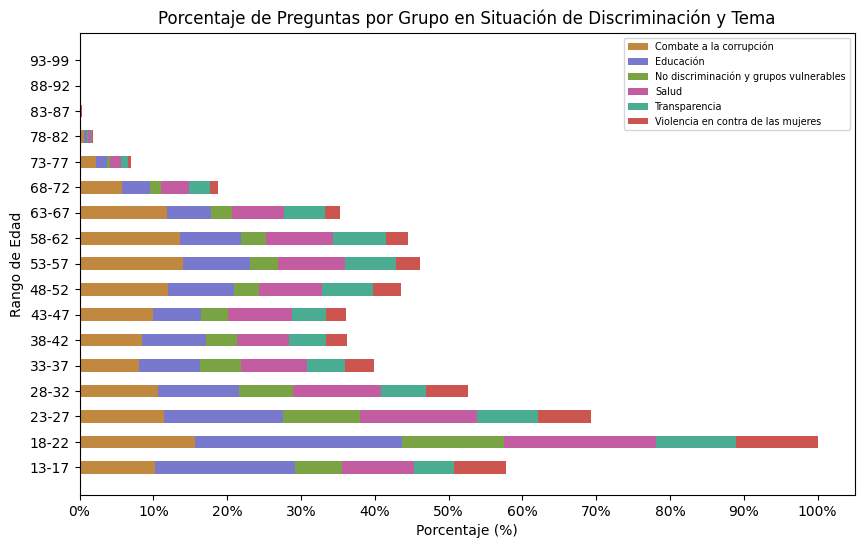

In [249]:
topic_color_palette = ["#c1883f", "#7878cd", "#7aa444", "#c45ca2", "#4aad92", "#cc554f"]

# Obtener el total de preguntas por cada rango de edad
total_preguntas_por_edad = pivot_df.sum(axis=1)

# Calcular los porcentajes para cada tema en base al grupo de edad con más preguntas
porcentajes_por_tema = (pivot_df.T / total_preguntas_por_edad.max(axis=0) * 100).T

fig, ax = plt.subplots(figsize=(10, 6))
barWidth = 0.5


for i, col in enumerate(porcentajes_por_tema.columns):
    ax.barh(porcentajes_por_tema.index, porcentajes_por_tema[col], height=barWidth, 
            left=np.sum(porcentajes_por_tema.iloc[:, :i], axis=1), label=col, color=topic_color_palette[i % len(topic_color_palette)])

# Etiquetas de porcentaje en el eje X
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xticklabels([f'{int(x)}%' for x in np.arange(0, 101, 10)])

plt.xlabel('Porcentaje (%)')
plt.ylabel('Rango de Edad')
plt.title('Porcentaje de Preguntas por Grupo en Situación de Discriminación y Tema')
plt.yticks(rotation=0)
plt.legend(fontsize='x-small', loc='upper right')
plt.show()


In [222]:
# Imprimir tabla de frecuencia de preguntas por Grupo en Situación de Discriminación y Tema
pivot_df

tema,Combate a la corrupción,Educación,No discriminación y grupos vulnerables,Salud,Transparencia,Violencia en contra de las mujeres
grupos_discriminacion,,,,,,
Personas adultas mayores,1047,599,258,659,494,216
Personas afromexicanas,40,37,22,20,19,12
Personas con discapacidad,255,311,251,326,118,110
Personas de la diversidad sexual,354,502,662,481,251,246
Personas indígenas,250,252,133,166,109,76
Personas mexicanas residentes en el extranjero,69,52,16,62,39,22
Personas migrantes,52,28,40,30,34,18


In [226]:
# Imprimir tabla de frecuencia de preguntas por Grupo en Situación de Discriminación y Tema
suma_total_por_grupo = pivot_df.sum(axis=1)

# Calcular los porcentajes
pivot_df_porcentajes = pivot_df.div(suma_total_por_grupo, axis=0) * 100

pivot_df_porcentajes

tema,Combate a la corrupción,Educación,No discriminación y grupos vulnerables,Salud,Transparencia,Violencia en contra de las mujeres
grupos_discriminacion,,,,,,
Personas adultas mayores,31.989001,18.301253,7.882676,20.134433,15.093187,6.599450
Personas afromexicanas,26.666667,24.666667,14.666667,13.333333,12.666667,8.000000
Personas con discapacidad,18.599562,22.684172,18.307805,23.778264,8.606856,8.023341
Personas de la diversidad sexual,14.182692,20.112179,26.522436,19.270833,10.056090,9.855769
Personas indígenas,25.354970,25.557809,13.488844,16.835700,11.054767,7.707911
Personas mexicanas residentes en el extranjero,26.538462,20.000000,6.153846,23.846154,15.000000,8.461538
Personas migrantes,25.742574,13.861386,19.801980,14.851485,16.831683,8.910891


## 5. Referencias

*   Instituto Nacional Electoral. (2024). Acuerdo INE/CG95/2024. Acuerdo del Consejo General del Instituto Nacional Electoral por el que se define la metodología, así como la instancia que seleccionará las preguntas provenientes de redes sociales relativas al Formato Tipo A que se utilizará en el Primer Debate Presidencial en el Proceso Electoral Federal 2023-2024. Repositorio Documental INE. https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/164296/CGex202402-08-ap-3.pdf
* Instituto Nacional Electoral. (2024). Anexo I. Metodología Selección de Preguntas para Debate Formato A. Recuperado de: https://repositoriodocumental.ine.mx/xmlui/bitstream/handle/123456789/164296/CGex202402-08-ap-3-a1.pdf